# Learning Patient Representations for Offline Reinforcement Learning in Healthcare

This notebook implements the experimental pipeline for evaluating the proposed Model Reduction Learning (MRL) framework on a sepsis treatment simulator. The workflow includes ground-truth MDP construction, MRL training, baseline comparison with FQI, and quantitative evaluation of both policy optimality and interpretability.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Thesis/MyThesis

/content/drive/MyDrive/Thesis/MyThesis


In [3]:
!pip install numpy-indexed

In [4]:
import sys
sys.path.append("sepsisSimDiabetes")
sys.path.append("mrl")

In [5]:
import itertools as it
import os
import shutil
import numpy as np
import pandas as pd
import pickle as pkl
from tqdm import tqdm_notebook as tqdm
import copy
import numpy_indexed as npi
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import random
import gc
from sklearn.metrics import (
    mutual_info_score,
    normalized_mutual_info_score,
)

In [6]:
from sepsisSimDiabetes.State import State
from sepsisSimDiabetes.Action import Action
from sepsisSimDiabetes.MDP import MDP
from sepsisSimDiabetes.DataGenerator import DataGenerator

In [7]:
from mrl.mdp_utils import *
from mrl.testing import *
from mrl.clustering import *
from mrl.model import MDP_model
from mrl.evaluation import *

# 1. Ground Truth MDP Construction

## Simulator

The experiments are conducted using the synthetic sepsis simulator proposed by Oberst and Sontag (2019). The simulator models sequential treatment decisions for septic patients as a finite Markov Decision Process (MDP), where patient states evolve according to predefined transition dynamics.

- **State space:** 720=3x3x2x5x2x2x2 observable states (1,440 including diabetes status).  
| Variable | Values |
|----------|--------|
| Heart Rate | Low (0), Normal (1), High (2) |
| Systolic BP | Low (0), Normal (1), High (2) |
| Oxygen Saturation | Low (0), Normal (1) |
| Glucose | Very Low (0), Low (1), Normal (2), High (3), Very High (4) |
| Antibiotics | Off (0), On (1) |
| Vasopressors | Off (0), On (1) |
| Ventilation | Off (0), On (1) |
| Diabetes (latent) | Non-diabetic (0), Diabetic (1) |

The initial glucose distribution is defined as **[0.05, 0.15, 0.60, 0.15, 0.05]** for non-diabetic patients and **[0.01, 0.05, 0.15, 0.60, 0.19]** for diabetic patients.

- **Action space:** 8 treatment actions, formed by administering or withholding antibiotics, vasopressors, and mechanical ventilation.  
| Treatment    | Values   |
| ------------ | -------- |
| Antibiotics  | Off (0), On (1) |
| Vasopressors | Off (0), On (1) |
| Ventilation  | Off (0), On (1) |

- **Transition:** Stochastic transitions determined by the simulator dynamics.
- **Reward**
  - +1: discharge (When all physiological variables are normal and no treatment is active)
  - -1: death (When 3 or more physiological variables are abnormal)
  - 0: intermediate states
- **Episode:** Maximum horizon of 20 decision steps.

Since the simulator provides the complete transition and reward mechanisms, the ground-truth MDP can be explicitly constructed. This enables direct computation of the optimal policy and value function, which serve as the reference for evaluating the learned RL policies.

In [ ]:
# Parameters
n_components = State.NUM_HID_STATES       # 2: non-diabetic / diabetic
n_actions = Action.NUM_ACTIONS_TOTAL      # 8
n_states = State.NUM_OBS_STATES           # 720
sink_idx = n_states                       # 720
n_states_with_sink = n_states + 1         # 721

## True Transition Matrix P

The ground-truth transition matrix `P_true` is constructed directly from the simulator dynamics. For each observable state-action pair, one-step transition probabilities are estimated by Monte Carlo simulation. Since the transition dynamics depend on the latent diabetes state, conditional transition probabilities are first estimated separately for diabetic and non-diabetic patients and then aggregated according to the p_diabetes.

To ensure consistency with the subsequent MRL formulation, an additional absorbing **sink state** is introduced, resulting in a **721-state** MDP (720 observable states + 1 sink state).
- P(terminal, sink) = 1
- P(sink, sink) = 1
- R(sink) = 0

In [ ]:
# Build P array
# =========================================================
# Repeat each (s, a, diabetic_idx) combination num_mc times
# 500 can be used for debugging first
num_mc = 500

P_true = np.zeros(
    (
        n_actions,
        n_states_with_sink,
        n_states_with_sink
    )
)
dummy_pol = np.ones((n_states, n_actions)) / n_actions


for s_idx in range(n_states):
    # Determine whether the observed state is a terminal death/discharge state.
    # diabetic_idx does not affect check_absorbing_state/calculateReward
    state_check = State(
        state_idx=s_idx,
        idx_type="obs",
        diabetic_idx=0
    )

    is_terminal = state_check.check_absorbing_state()

    # terminal states -> sink
    if is_terminal:
        for a_idx in range(n_actions):
            P_true[
                a_idx,
                s_idx,
                sink_idx
            ] = 1.0

        continue

    # non-terminal states -> estimate transition by Monte Carlo
    for a_idx in range(n_actions):
        action = Action(action_idx=a_idx)
        next_probs = np.zeros(n_states_with_sink)
        # obs state transition depends on hidden diabetic_idx
        # estimate conditional transitions for diabetic_idx = 0 and 1,
        # then mix using p_diabetes
        for diabetic_idx, weight in [(0, 0.8), (1, 0.2)]:
            mdp = MDP(
                init_state_idx=s_idx,
                init_state_idx_type="obs",
                policy_array=dummy_pol,
                policy_idx_type="obs",
                p_diabetes=0.2
            )

            component_counts = np.zeros(n_states_with_sink)

            for _ in range(num_mc):

                # reset state before every one-step query
                mdp.state = State(
                    state_idx=s_idx,
                    idx_type="obs",
                    diabetic_idx=diabetic_idx
                )

                reward = mdp.transition(action)

                next_s_idx = int(
                    mdp.state.get_state_idx(
                        idx_type="obs"
                    )
                )

                component_counts[next_s_idx] += 1

            component_probs = component_counts / component_counts.sum()

            next_probs += weight * component_probs

        P_true[
            a_idx,
            s_idx,
            :
        ] = next_probs


# sink -> sink
for a_idx in range(n_actions):
    P_true[
        a_idx,
        sink_idx,
        sink_idx
    ] = 1.0


print("P_true shape:", P_true.shape)

row_sums = P_true.sum(axis=2)
bad_rows = np.where(
    ~np.isclose(row_sums, 1.0)
)
print("bad rows:", bad_rows)
print("num bad rows:", len(bad_rows[0]))

P_true shape: (8, 721, 721)
bad rows: (array([], dtype=int64), array([], dtype=int64))
num bad rows: 0


## True Reward Matrix R

Construct the ground-truth reward vector `R_true` directly from the simulator reward function.

In [ ]:
# Build R array
# =========================================================
components = [0, 1]
states = range(n_states)
actions = range(n_actions)
dummy_pol = np.ones((n_states, n_actions)) / n_actions

# =========================================================
# Build state-level true reward vector: R[s]
# =========================================================
R_true = np.zeros(n_states_with_sink)

for s_idx in states:
    # set p_diabetes=0/diabetic_idx=0 to initialize
    mdp = MDP(
        init_state_idx=s_idx,
        init_state_idx_type='obs',
        policy_array=dummy_pol,
        policy_idx_type='obs',
        p_diabetes=0
    )

    R_true[s_idx] = mdp.calculateReward()

R_true[sink_idx] = 0

print("R_true shape:", R_true.shape)
print("num death states (-1):", np.sum(R_true == -1))
print("num neutral states (0):", np.sum(R_true == 0))
print("num discharge states (+1):", np.sum(R_true == 1))

R_true shape: (721,)
num death states (-1): 416
num neutral states (0): 304
num discharge states (+1): 1


## Solve the Ground Truth MDP

Solve the ground-truth MDP using Value Iteration.

- Obtain the optimal policy `true_pi`
- Cache the optimal policy for subsequent experiments (reduce computation time)

In [8]:
# Solve true_v, true_pi
# =========================================================
# Cache & Reload true_v, true_pi
# =========================================================
cache_dir = "./cache"
os.makedirs(cache_dir, exist_ok=True)

cache_file = os.path.join(cache_dir, "true_policy_gamma1.npz")

if os.path.exists(cache_file):
    data = np.load(cache_file)
    true_v = data["true_v"]
    true_pi = data["true_pi"]
    print("Loaded cached true_v / true_pi")
else:
    true_v, true_pi = SolveMDP(
        P_true,
        R_true,
        prob="max",
        gamma=1,
        epsilon=1e-8,
    )

    np.savez(
        cache_file,
        true_v=true_v,
        true_pi=true_pi,
    )

    print("Computed and cached true_v / true_pi")

print(true_v)
print(true_pi.shape)
print(true_pi)

Loaded cached true_v / true_pi
[-1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
  2.48702251e-01  2.64880007e-01  2.53646063e-01  2.6744411

# 2. Minimal Representation Learning (MRL) Model

Sample a full training dataset **D** from the simulator, configure the MRL model parameters, fit the model, solve the resulting reduced MDP, and inspect the learned policy, state representation, and returned training outputs.

## Genrate Trajectories D (Sepsis Simulator)

All datasets are generated using the sepsis simulator under a uniformly random behavior policy.

- State space: `720` observed states (State.NUM_OBS_STATES)
- Action space: `8` discrete treatment actions (Action.NUM_ACTIONS_TOTAL)
- Behavior policy: Uniform random policy, where each action is selected with probability 1/8. This encourages unbiased exploration of the state-action space and provides sufficient coverage for offline reinforcement learning.
- Maximum trajectory length: `20` time steps. This parameter is specified to balance state-action coverage and computational efficiency. (Preliminary experiments showed that further increasing the trajectory length produced only marginal improvements in state-action coverage while substantially increasing the dataset size.)
- Number of trajectories: `3000`. Under the chosen horizon of 20 steps, approximately 3000 trajectories provide a practical balance between state-action coverage and data collection cost. (Beyond this point, additional trajectories yield diminishing improvements in coverage.)
- Latent diabetes prevalence: `p
diabetes = 0.2`, matching the default simulator configuration.

The random behavior policy is represented by a policy matrix of shape (720, 8), where each row sums to one.

In [ ]:
# Build DataGenerator policies
# =========================================================
# policy shape (n_states, n_actions)
n_states = State.NUM_OBS_STATES          # 720
n_actions = Action.NUM_ACTIONS_TOTAL     # 8

num_trajectories = 3000
# num_trajectories = 1000
max_num_steps = 20
p_diabetes = 0.2

random_policy = np.ones((n_states, n_actions)) / n_actions

assert random_policy.shape == (n_states, n_actions)
assert np.allclose(random_policy.sum(axis=1), 1.0)

In [ ]:
# Sample D from Sepsis Simulator
# =========================================================
dg = DataGenerator()

iter_states, iter_actions, iter_lengths, iter_rewards, iter_component, emp_tx_mat, emp_r_mat = dg.simulate(
    num_iters=num_trajectories,
    max_num_steps=max_num_steps,
    policy=random_policy,
    policy_idx_type='obs',
    p_diabetes=p_diabetes,
    output_state_idx_type='obs',
    use_tqdm=True,
    tqdm_desc='Generating trajectories'
)

Generating trajectories:   0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
# Display the shapes of the generated outputs
print("iter_states shape:", iter_states.shape)
print("iter_actions shape:", iter_actions.shape)
print("iter_lengths shape:", iter_lengths.shape)
print("iter_rewards shape:", iter_rewards.shape)
print("iter_component shape:", iter_component.shape)
print("emp_tx_mat shape:", emp_tx_mat.shape)
print("emp_r_mat shape:", emp_r_mat.shape)

# Display the first trajectory
traj_id = 0
length = int(iter_lengths[traj_id, 0])

print("\n=== Trajectory 0 ===")
print("diabetic component:", int(iter_component[traj_id, 0, 0]))
print("length:", length)
print("states:", iter_states[traj_id, :length+1, 0])
print("actions:", iter_actions[traj_id, :length+1, 0])
print("rewards:", iter_rewards[traj_id, :length+1, 0])

# Summarize terminal outcomes
# Rewards are non-zero only at the terminal step,
# so summing over time yields the terminal reward for each trajectory.
terminal_rewards = iter_rewards.sum(axis=1).flatten()

print("\n=== Terminal reward summary ===")
print("num +1 terminal:", np.sum(terminal_rewards == 1))
print("num -1 terminal:", np.sum(terminal_rewards == -1))
print("num zero terminal (not ended within max_num_steps):", np.sum(terminal_rewards == 0))

iter_states shape: (3000, 21, 1)
iter_actions shape: (3000, 21, 1)
iter_lengths shape: (3000, 1)
iter_rewards shape: (3000, 21, 1)
iter_component shape: (3000, 21, 1)
emp_tx_mat shape: (8, 720, 720)
emp_r_mat shape: (8, 720, 720)

=== Trajectory 0 ===
diabetic component: 0
length: 1
states: [ 96 178]
actions: [ 1 -1]
rewards: [ 0. -1.]

=== Terminal reward summary ===
num +1 terminal: 145
num -1 terminal: 2463
num zero terminal (not ended within max_num_steps): 392


In [ ]:
# Generate long df of sample D
df_scheme_a = dg_to_df_mrl(
    iter_states=iter_states,
    iter_actions=iter_actions,
    iter_lengths=iter_lengths,
    iter_rewards=iter_rewards,
    iter_component=iter_component
)


df_scheme_a.head(50)

,ID,TIME,FEATURE_0,FEATURE_1,FEATURE_2,FEATURE_3,FEATURE_4,FEATURE_5,FEATURE_6,ACTION,RISK
0,0,0,0,1,0,2,0,0,0,1,0.0
1,0,1,0,2,0,2,0,1,0,None,-1.0
2,1,0,1,1,0,2,0,0,0,1,0.0
3,1,1,1,2,0,2,0,1,0,1,0.0
4,1,2,1,2,0,2,0,1,0,7,0.0
5,1,3,1,1,1,2,1,1,1,4,0.0
6,1,4,1,1,1,2,1,0,0,6,0.0
7,1,5,1,1,1,2,1,0,1,4,0.0
8,1,6,1,1,1,2,1,0,0,1,0.0
9,1,7,1,1,1,2,0,1,0,3,0.0


## MRL Model Fit

Breakdown of MRL parameters:

- `data`: Dataframe derived from sample D, in the format ['ID', 'TIME', ...features..., 'RISK', 'ACTION']
- `pfeatures`: Number of features in the dataset, in this experiment 7 features.
- `h`: Number of time steps (horizon) on which to evaluate the value error. When `h = -1`, we evaluate over an infinite horizon, the whole path. Defaults to 5.  
- `gamma`: MDP discount factor used when calculating values (in particular evaluating value error). Defaults to 1.  
- `max_k`: Maximum number of clusters we allow. Defaults to 70.
- `distance_threshold`: Clustering diameter for Agglomerative clustering. Defaults to 0.05.
- `th`: Splitting threshold. Defaults to 0.05.     
> - `eta`: Only relevant in deterministic setting. Incoherence threshold. Defaults to float('inf').
- `precision_thresh`: Minimum decrease in value error necessary for the model to determine that a split gives a better clustering/representation.  *Further Notes:* This value attempts to limit model complexity when improvements becomes only incremental. Defaults to 1e-14.
- `classification`: Classifier used to estimate the transition probability distribution. In the stochastic setting, the classifier is fitted globally to predict the next metastate
from the state features and action. Options for this classifier include `'DecisionTreeClassifier'`, `'LogisticRegression'`, `'RandomForestClassifier'`, `'MLPClassifier'`, and `'AdaBoostClassifier'`. Defaults to 'DecisionTreeClassifier'.
- `split_classifier_params`: Parameters for the classification method.
- `clustering`: Clustering method used to form the initial clusters (based on rewards). Options for this clustering method include  `'Agglomerative'`, `'KMeans'`, or `'Birch'`. Defaults to 'Agglomerative'.
> - `n_clusters`: Number of clusters for `'KMeans'` and `'Birch'`. For `'Agglomerative'`, this parameter is optional. When rewards are continuous, it may be used to specify the desired number of initial clusters. In our setting, rewards are discrete, so the initialization is controlled by `distance_threshold`, and `n_clusters` is not used. Defaults to `None`.  
> - `random_state`: Random state for initial clustering reproducibility if using `KMeans`. Defaults to 0.
- `plot`: Flag to plot the results. Defaults to False.
- `optimize`: Whether to return the best cluster representation found during splitting instead of the final split. Defaults to True.
> - `verbose`: Verbosity flag. Defaults to False.
> - `save_epoch`: Flag to save the model at each epoch. Defaults to False.
> - `save_path`: Path to save the model. Defaults to None.
> - `save_every`: Interval to save the model. Defaults to 1.
- `eval_samples`: Number or proportion of training trajectories used to estimate the training value error at each split. If None, all training trajectories are used. If an integer, that many trajectories are sampled uniformly without replacement. If a float in (0, 1], that proportion of trajectories is sampled. Defaults to None.
- `stochastic`: Flag to use stochastic MDP. Defaults to False.

In [ ]:
# Parameters for model fitting
# =========================================================
data = df_scheme_a
pfeatures = 7
h = -1
# gamma = 1
max_k = 250
distance_threshold = 0.5
# th = 0.05
# precision_thresh = 1e-14
classification = 'DecisionTreeClassifier'
split_classifier_params = {'random_state':0, 'max_depth': None}
# clustering = 'Agglomerative'
plot=True
# optimize=True
# eval_samples=None
stochastic=True

copied data
initializing clusters...
Clusters Initialized


Splitting... |#Clusters:3:   0%|          | 0/247 [00:00<?, ?it/s]

overall weighted heterogeneity: 0.1439825075969654
absolute threshold: 0.05
max group heterogeneity: 0.20361871431243772
q90: 0.19401992233883225
will stop: False
chosen: (np.int64(0), np.int64(1))
Split Success


Splitting... |#Clusters:4:   0%|          | 1/247 [00:01<06:16,  1.53s/it]

overall weighted heterogeneity: 0.15797277082401184
absolute threshold: 0.05
max group heterogeneity: 0.4088766442633346
q90: 0.3486723976399414
will stop: False
chosen: (np.int64(3), np.int64(6))
Split Success


...

overall weighted heterogeneity: 0.050807690996265295
absolute threshold: 0.05
max group heterogeneity: 0.18
q90: 0.051665112190742775
will stop: False
chosen: (np.int64(200), np.int64(5))
Split Success


Splitting... |#Clusters:202:  81%|████████  | 199/247 [10:45<03:46,  4.72s/it]

overall weighted heterogeneity: 0.05036574626586203
absolute threshold: 0.05
max group heterogeneity: 0.12
q90: 0.04856957899311368
will stop: False
chosen: (np.int64(26), np.int64(6))
Split Success


Splitting... |#Clusters:203:  81%|████████  | 200/247 [10:52<02:33,  3.26s/it]

overall weighted heterogeneity: 0.04996930941611415
absolute threshold: 0.05
max group heterogeneity: 0.11801469881248891
q90: 0.04281487800673716
will stop: True
chosen: (-1, -1)


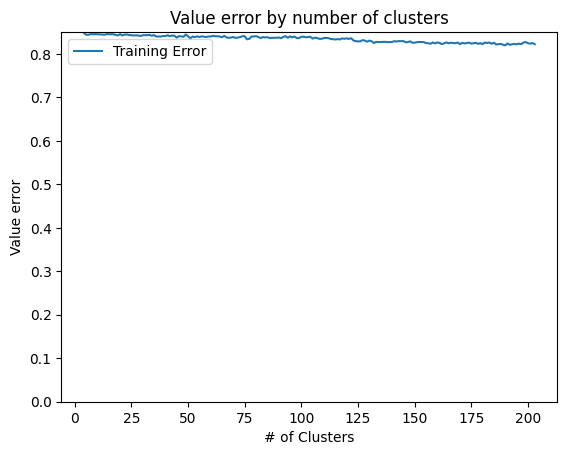

In [ ]:
# Fit the MRL model and learn the minimal state representation
# =========================================================
m = MDP_model()
m.fit(data = data,
    pfeatures = pfeatures,
    h = h,
    # gamma = gamma,
    max_k = max_k,
    distance_threshold = distance_threshold,
    # th =th,
    # precision_thresh = precision_thresh,
    classification = classification,
    split_classifier_params = split_classifier_params,
    # clustering = clustering,
    plot=True,
    # optimize=True,
    # eval_samples=None,
    stochastic=True)


In [ ]:
# =========================================================
# Cache the fitted model and coherence diagnostics
# =========================================================
single_fit_dir = os.path.join(cache_dir, "single_mrl_fit")
os.makedirs(single_fit_dir, exist_ok=True)

# Save the complete fitted MRL model
with open(os.path.join(single_fit_dir, "mrl_model.pkl"), "wb") as f:
    pkl.dump(m, f)

# Save the coherence diagnostics separately for convenient analysis
coherence_df = pd.DataFrame(m.coherence_history)

coherence_df.to_pickle(
    os.path.join(single_fit_dir, "coherence_diagnostic_df.pkl")
)

In [9]:
coherence_df = pd.read_pickle(
    os.path.join(
        cache_dir,
        "single_mrl_fit/coherence_diagnostic_df.pkl"
    )
)

display(coherence_df)

,K,max_score,overall_score,q90_score,median_score,n_groups
0,3,0.203619,0.143983,0.194020,0.160131,8
1,4,0.408877,0.157973,0.348672,0.214442,16
2,5,0.349776,0.150348,0.307035,0.239923,24
3,6,0.313290,0.148110,0.290610,0.235314,32
4,7,0.315370,0.145076,0.281612,0.222503,40
...,...,...,...,...,...,...
196,199,0.121477,0.051687,0.052798,0.000000,1294
197,200,0.120989,0.051319,0.052136,0.000000,1302
198,201,0.180000,0.050808,0.051665,0.000000,1310
199,202,0.120000,0.050366,0.048570,0.000000,1318


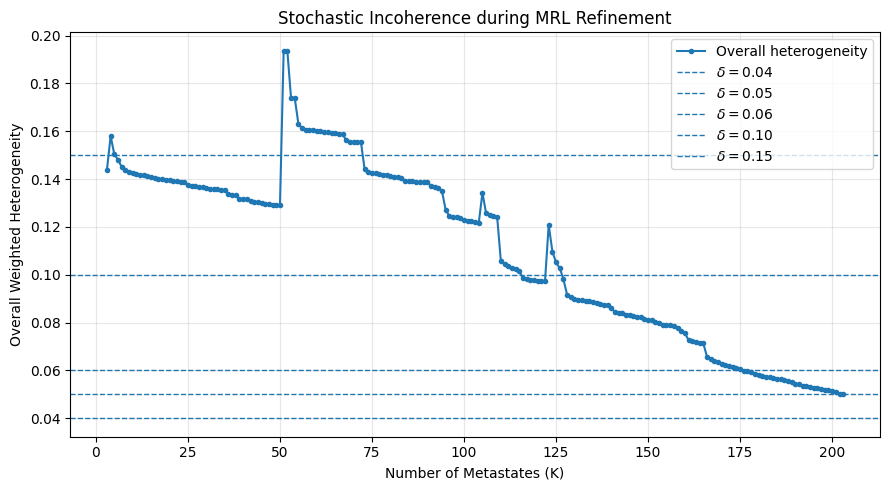

In [11]:
# coherence_df = pd.DataFrame(m.coherence_history)

candidate_thresholds = [0.04, 0.05, 0.06, 0.10, 0.15]

plt.figure(figsize=(9, 5))

plt.plot(
    coherence_df["K"],
    coherence_df["overall_score"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Overall heterogeneity"
)

for th in candidate_thresholds:
    plt.axhline(
        y=th,
        linestyle="--",
        linewidth=1,
        label=rf"$\delta = {th:.2f}$"
    )

plt.xlabel("Number of Metastates (K)")
plt.ylabel("Overall Weighted Heterogeneity")
plt.title("Stochastic Incoherence during MRL Refinement")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## MRL Model Inspection

In [ ]:
# =========================================================
# Load the fitted MRL model
# =========================================================
single_fit_dir = os.path.join(cache_dir, "single_mrl_fit")

with open(os.path.join(single_fit_dir, "mrl_model.pkl"), "rb") as f:
    m = pkl.load(f)

In [ ]:
# =========================================================
# 1. Basic information of the trained MRL model
# =========================================================
print("=" * 60)
print("Basic model information")
print("=" * 60)

print(f"Optimal K: {m.opt_k}")
print(f"Effective clusters: {m.df_trained['CLUSTER'].nunique()}")
print(f"Maximum cluster label: {m.df_trained['CLUSTER'].max()}")

print("=" * 60)
print("Cluster sizes")
print("=" * 60)

cluster_size = (
    m.df_trained
    .groupby("CLUSTER")
    .size()
    .rename("COUNT")
    .sort_values(ascending=False)
)

display(cluster_size)

print("=" * 60)
print("Action distribution")
print("=" * 60)

display(
    pd.crosstab(
        m.df_trained["CLUSTER"],
        m.df_trained["ACTION"]
    )
)

Basic model information
Optimal K: 190
Effective clusters: 190
Maximum cluster label: 189
Cluster sizes


,COUNT
CLUSTER,
52,3333
127,3244
0,3104
1,2463
50,2337
...,...
12,1
40,1
69,1


Action distribution


ACTION,0,1,2,3,4,5,6,7,None
CLUSTER,,,,,,,,,
0,402,387,392,390,365,385,385,398,0
1,0,0,0,0,0,0,0,0,2463
2,0,0,0,0,0,0,0,0,145
3,12,10,19,23,17,17,17,15,0
4,35,29,45,39,32,30,37,31,0
...,...,...,...,...,...,...,...,...,...
185,18,15,12,14,18,14,17,15,0
186,2,2,3,1,2,2,0,2,0
187,23,15,11,11,15,11,13,18,0


In [ ]:
# =========================================================
# 2. Trained dataframe
# =========================================================
print("=" * 60)
print("Trained dataframe")
print("=" * 60)

display(
    m.df_trained.head(20)
)

print("\nDataframe shape:")
print(m.df_trained.shape)

Trained dataframe


,ID,TIME,FEATURE_0,FEATURE_1,FEATURE_2,FEATURE_3,FEATURE_4,FEATURE_5,FEATURE_6,ACTION,RISK,CLUSTER,NEXT_CLUSTER
0,0,0,0,1,0,2,0,0,0,1,0.0,9,1
1,0,1,0,2,0,2,0,1,0,None,-1.0,1,End
2,1,0,1,1,0,2,0,0,0,1,0.0,111,185
3,1,1,1,2,0,2,0,1,0,1,0.0,185,185
4,1,2,1,2,0,2,0,1,0,7,0.0,185,140
5,1,3,1,1,1,2,1,1,1,4,0.0,140,140
6,1,4,1,1,1,2,1,0,0,6,0.0,140,140
7,1,5,1,1,1,2,1,0,1,4,0.0,140,140
8,1,6,1,1,1,2,1,0,0,1,0.0,140,141
9,1,7,1,1,1,2,0,1,0,3,0.0,141,52



Dataframe shape:
(29277, 13)


In [ ]:
# =========================================================
# 3. Construct learned stochastic MDP
# =========================================================
P_df, R_df = get_MDP_stochastic(m.df_trained)

print("=" * 60)
print("Learned MDP")
print("=" * 60)

print(f"P_df shape : {P_df.shape}")
print(f"R_df shape : {R_df.shape}")

Learned MDP
P_df shape : (3427, 4)
R_df shape : (191,)


In [ ]:
# =========================================================
# 4. Reward function
# =========================================================
print("=" * 60)
print("Reward table")
print("=" * 60)

display(
    R_df.sort_index()
)

Reward table


,0
0,0.0
1,-1.0
2,1.0
3,0.0
4,0.0
...,...
186,0.0
187,0.0
188,0.0
189,0.0


In [ ]:
# =========================================================
# 5. Transition table (multi-index)
# =========================================================
P_df_lookup = (
    P_df
    .sort_values(
        ["CLUSTER", "ACTION", "NEXT_CLUSTER"]
    )
    .set_index(
        ["CLUSTER", "ACTION", "NEXT_CLUSTER"]
    )
)

display(
    P_df_lookup.head(30)
)

print("\nTotal transitions:")
print(len(P_df_lookup))

PROBABILITY
CLUSTER ACTION NEXT_CLUSTER             
0       0      0                0.609827
               1                0.205202
               2                0.002890
               50               0.054913
               52               0.005780
               80               0.002890
               125              0.008671
               136              0.005780
               160              0.002890
               167              0.098266
               178              0.002890
        1      0                0.797619
               1                0.196429
               52               0.005952
        2      0                0.026316
               1                0.154971
               25               0.005848
               27               0.002924
               38               0.640351
               50               0.058480
               52               0.011696
               125              0.002924
               151              0.090643
               187              0.005848
        3      0                0.830357
               1                0.157738
               52               0.008929
               156              0.002976
        4      0                0.404255
               1                0.048632


Total transitions:
3427


In [ ]:
# =========================================================
# 6. Solve the learned MDP
# =========================================================

m.solve_MDP(
    alpha=0.2,
    beta=0.8,
    min_action_obs=-1,
    min_action_purity=0.7,
    prob="max",
    gamma=0.99,
    epsilon=1e-8,
    p=True,  # Print the optimization results
)

# =========================================================
# 7. Optimal value function and policy
# =========================================================

optimal_values = m.v
optimal_policy = m.pi

print("=" * 60)
print("Optimal MDP Solution")
print("=" * 60)

print("\nOptimal value function V:")
print(optimal_values)

print("\nOptimal policy π:")
print(optimal_policy)

print("\nNumber of learned states:")
print(len(optimal_values))

print("\nPolicy shape:")
print(np.shape(optimal_policy))

Optimal Value: [ -1.31745496  -1.           1.         -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
  -1.61965269 -39.6        -14.0291498  -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -39.6        -39.6
 -39.6        -39.6        -39.6        -

,SIZE,N_ACTIONS,ACTION_COVERAGE,RANK
CLUSTER,,,,
52,3333,8.0,1.0,1
127,3244,8.0,1.0,2
0,3104,8.0,1.0,3
1,2463,NaN,NaN,4
50,2337,8.0,1.0,5
140,1504,8.0,1.0,6
93,1233,8.0,1.0,7
174,610,8.0,1.0,8
54,553,8.0,1.0,9


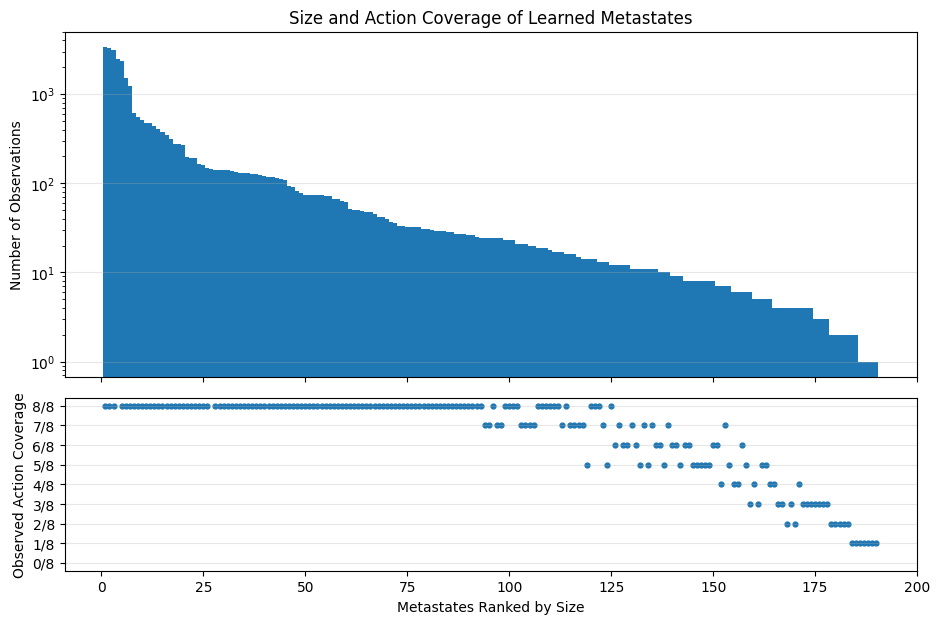

In [ ]:
# =========================================================
# 7. Cluster summary: size and action coverage
# =========================================================

df = m.df_trained.copy()

# --------------------------------------------------
# Metastate size
# --------------------------------------------------
cluster_size = (
    df.groupby("CLUSTER")
    .size()
    .rename("SIZE")
)

# --------------------------------------------------
# Action coverage: Exclude terminal observations with ACTION=None
# --------------------------------------------------
valid_actions = df[
    df["ACTION"].notna() &
    (df["ACTION"].astype(str) != "None")
].copy()

n_actions_observed = (
    valid_actions.groupby("CLUSTER")["ACTION"]
    .nunique()
    .rename("N_ACTIONS")
)

# --------------------------------------------------
# Combine metastate size and action coverage
# --------------------------------------------------
summary = pd.concat([cluster_size, n_actions_observed], axis=1)
summary["ACTION_COVERAGE"] = summary["N_ACTIONS"] / 8

# Rank metastates by decreasing size
summary = summary.sort_values("SIZE", ascending=False)
summary["RANK"] = np.arange(1, len(summary) + 1)

display(summary.head(20))


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1],
        "hspace": 0.08
    }
)
x = summary["RANK"].to_numpy()

# Panel A: metastate size
ax1.bar(
    x,
    summary["SIZE"].to_numpy(),
    width=1.0
)

ax1.set_yscale("log")
ax1.set_ylabel("Number of Observations")
ax1.set_title("Size and Action Coverage of Learned Metastates")
ax1.grid(axis="y", alpha=0.3)


# Panel B: Observed action coverage
# Terminal states with no available action are excluded
non_terminal = summary["ACTION_COVERAGE"].notna()
ax2.scatter(
    summary.loc[non_terminal, "RANK"],
    summary.loc[non_terminal, "ACTION_COVERAGE"],
    s=12
)

ax2.set_ylim(-0.05, 1.05)
coverage_ticks = np.arange(0, 9) / 8
ax2.set_yticks(coverage_ticks)
ax2.set_yticklabels(
    [f"{i}/8" for i in range(9)]
)

ax2.set_ylabel("Observed Action Coverage")
ax2.set_xlabel("Metastates Ranked by Size")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Optional: save for LaTeX
# plt.savefig(
#     "figures/metastate_summary.pdf",
#     bbox_inches="tight"
# )

plt.show()

# 3. Performance Evaluation

This section evaluates the performance of the proposed stochastic MRL algorithm from two complementary perspectives.

First, **policy optimality** is assessed by comparing the policy learned from the compressed MDP with the ground-truth policy derived from the simulator. This evaluation measures the extent to which the MDP learned by MRL preserves decision-relevant information, enabling the compressed MDP to recover the decision quality of the original MDP.

Second, **interpretability** is evaluated by examining whether the learned state representation preserves clinically meaningful structure. This includes both state-level and policy-level analyses, as well as the ability of the learned metastates to recover the simulator's hidden diabetes state.

## Optimality Gap & Data Size N (10 Trials )

The optimality evaluation compares policies learned by stochastic MRL and a baseline tabular Fitted Q Iteration (FQI) using identical simulated datasets. The learned policy value `V_learned` is estimated by Monte Carlo rollouts. The ground-truth optimal value `V_true` is estimated from the simulator and serves as the reference.

**The optimality gap is defined as `∣V_true − V_learned∣`.**

In [ ]:
# =========================================================
# Repeated experiment settings
# =========================================================
n_repeats = 10
N_full = 3000

# Ns = [100] # DEBUG
# Ns = [100, 200, 500] # DEBUG
Ns = [100, 200, 500, 1000, 1500, 2000, 2500, 3000]

max_num_steps = 20
p_diabetes = 0.2
nS = State.NUM_OBS_STATES
nA = Action.NUM_ACTIONS_TOTAL
random_policy = np.ones((nS, nA)) / nA

Estimate `V_true` by evaluating the simulator's optimal policy (`true_pi`) using `5,000` Monte Carlo rollouts with a discount factor of `γ=0.99`.

In [ ]:
# =========================================================
# Evaluation settings
# =========================================================
gamma_eval = 0.99
num_eval_rollouts = 5000

# Remove sink states from the true policy
true_pi_dg = true_pi[:nS]

true_policy_array = deterministic_pi_to_prob_array(
    true_pi_dg,
    num_actions=nA,
)

# Evaluate true optimal policy once
V_true, true_returns = estimate_policy_value(
    policy_array=true_policy_array,
    num_iters=num_eval_rollouts,
    max_num_steps=max_num_steps,
    gamma=gamma_eval,
    policy_idx_type="obs",
    output_state_idx_type="obs",
    p_diabetes=p_diabetes,
    use_tqdm=True,
    tqdm_desc="True optimal policy",
)

print("Estimated V_true:", V_true)

True optimal policy:   0%|          | 0/5000 [00:00<?, ?it/s]

Estimated V_true: 0.1993842519939881


For MRL, an MDP is first learned from the compressed state representation, after which **Value Iteration** is applied to compute the optimal policy. For **FQI**, a tabular implementation is used with `100` Bellman iterations.

Unobserved state-action pairs are initialized with a large negative value `G
min = −40` for FQI, corresponding to the sink-state penalty mechanism introduced in the compressed MDP.

In [ ]:
# =========================================================
# FQI parameters
# =========================================================
fqi_epochs = 100
G_min = -40

# =========================================================
# MRL parameters
# =========================================================

pfeatures = 7
h = 5
gamma_mrl = 0.99
max_k = 250
distance_threshold = 0.5
th = 0.05
precision_thresh = 1e-14
classification = 'DecisionTreeClassifier'
split_classifier_params_base = {"max_depth": None,}
clustering = 'Agglomerative'
plot=True
# optimize=True
eval_samples=None
stochastic=True

For each independent trial, a dataset containing `N = 3000` trajectories is first generated from the simulator under the random behavior policy. Smaller datasets are then obtained by selecting the first `N` trajectories from the same dataset, ensuring that both algorithms are trained on exactly the same samples for every sample size.

The entire experiment is repeated 10 times using different random seeds. Results are summarized using the mean of optimality gaps across the 10 trials.

In [ ]:
# =========================================================
# Result matrices
# rows: independent repeats
# columns: different N values
# =========================================================
fqi_gap_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

mrl_gap_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

fqi_value_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

mrl_opt_k_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

# =========================================================
# Save latent-state information
# One entry for each independent repeat
# =========================================================
diabetes_maps = {}
maxN_cluster_maps = {}
N_max = max(Ns)

# Optional: keep fitted models.
# This can consume substantial memory, so it is disabled by default.
all_mrl_models = []

In [ ]:
# =========================================================
# Cache directory for fitted MRL models
# =========================================================
model_cache_dir = os.path.join(cache_dir, "mrl_models")

# Clear previously cached MRL models
if os.path.exists(model_cache_dir):
    shutil.rmtree(model_cache_dir)

os.makedirs(model_cache_dir, exist_ok=True)

# =========================================================
# Outer loop: 10 independently generated N=3000 datasets
# =========================================================
for repeat_idx in range(n_repeats):

    data_seed = repeat_idx

    np.random.seed(data_seed)
    random.seed(data_seed)

    print("\n" + "=" * 80)
    print(
        f"Independent experiment "
        f"{repeat_idx + 1}/{n_repeats}, "
        f"data seed={data_seed}"
    )
    print("=" * 80)

    # -----------------------------------------------------
    # 1. Generate one complete N=3000 dataset
    # -----------------------------------------------------
    dg_repeat = DataGenerator()

    (
        iter_states,
        iter_actions,
        iter_lengths,
        iter_rewards,
        iter_component,
        emp_tx_mat,
        emp_r_mat,
    ) = dg_repeat.simulate(
        num_iters=N_full,
        max_num_steps=max_num_steps,
        policy=random_policy,
        policy_idx_type="obs",
        p_diabetes=p_diabetes,
        output_state_idx_type="obs",
        use_tqdm=True,
        tqdm_desc=(
            f"Generating dataset "
            f"{repeat_idx + 1}/{n_repeats}"
        ),
    )

    # diabetes map for MRL diabetic recovery evaluation
    # Save the initial diabetes labels as this information is not retained in the generated df
    diabetes_map = {}
    for traj in range(iter_component.shape[0]):
      diabetes_map[traj] = int(iter_component[traj, 0, 0])

    diabetes_maps[repeat_idx] = diabetes_map

    # -----------------------------------------------------
    # 2. Convert the same trajectories to df formats
    # -----------------------------------------------------
    df_mrl_full = dg_to_df_mrl(
        iter_states=iter_states,
        iter_actions=iter_actions,
        iter_lengths=iter_lengths,
        iter_rewards=iter_rewards,
        iter_component=iter_component,
    )

    df_fqi_full = dg_to_df_fqi(
        iter_states=iter_states,
        iter_actions=iter_actions,
        iter_lengths=iter_lengths,
        iter_rewards=iter_rewards,
    )

    # Check that both contain the same trajectory IDs
    assert df_mrl_full["ID"].nunique() == N_full
    assert df_fqi_full["ID"].nunique() == N_full

    models = []

    # =====================================================
    # Inner loop: different sample sizes Ns from this dataset
    # =====================================================
    for n_idx, N in enumerate(Ns):

        print("\n" + "-" * 70)
        print(
            f"Repeat={repeat_idx + 1}, "
            f"N={N}"
        )
        print("-" * 70)

        # -------------------------------------------------
        # 3. Use exactly the same trajectory IDs for both
        # -------------------------------------------------
        df_fqi_N = df_fqi_full.loc[
            df_fqi_full["ID"] < N
        ].copy()

        df_mrl_N = df_mrl_full.loc[
            df_mrl_full["ID"] < N
        ].copy()

        assert df_fqi_N["ID"].nunique() == N
        assert df_mrl_N["ID"].nunique() == N

        # =================================================
        # 4. FQI fit and evaluation
        # =================================================
        print(f"\nFQI fitting: repeat={repeat_idx + 1}, N={N}")

        Qs_N = run_tabular_FQI(
            df_data=df_fqi_N,
            gamma=gamma_eval,
            n_epochs=fqi_epochs,
            nS=nS,
            nA=nA,
            G_min=G_min,
            use_tqdm=True,
        )

        # Use the converged Q-table from the final FQI iteration
        Q_N = Qs_N[-1]

        pi_fqi_N = np.argmax(
            Q_N,
            axis=1,
        )

        fqi_policy_array = deterministic_pi_to_prob_array(
            pi_fqi_N,
            num_actions=nA,
        )

        V_fqi_N, returns_fqi_N = estimate_policy_value(
            policy_array=fqi_policy_array,
            num_iters=num_eval_rollouts,
            max_num_steps=max_num_steps,
            gamma=gamma_eval,
            policy_idx_type="obs",
            output_state_idx_type="obs",
            p_diabetes=p_diabetes,
            use_tqdm=True,
            tqdm_desc=(
                f"FQI evaluation: "
                f"repeat={repeat_idx + 1}, N={N}"
            ),
        )

        fqi_gap_N = abs(
            V_true - V_fqi_N
        )

        fqi_value_matrix[
            repeat_idx,
            n_idx,
        ] = V_fqi_N

        fqi_gap_matrix[
            repeat_idx,
            n_idx,
        ] = fqi_gap_N

        # =================================================
        # 5. MRL fit
        # =================================================
        print(f"\nMRL fitting: repeat={repeat_idx + 1}, N={N}")

        # Make the model-fitting randomness reproducible.
        # Different repeats receive different seeds.
        model_seed = repeat_idx

        split_classifier_params = {
            **split_classifier_params_base,
            "random_state": model_seed,
        }

        m_N = MDP_model()

        m_N.fit(
            data = df_mrl_N,
            pfeatures = pfeatures,
            h = h,
            gamma = gamma_mrl,
            max_k = max_k,
            distance_threshold = distance_threshold,
            th = th,
            precision_thresh = precision_thresh,
            classification = classification,
            split_classifier_params = split_classifier_params,
            clustering = clustering,
            random_state = model_seed,
            plot=False,
            eval_samples=eval_samples,
            stochastic=True
        )

        models.append(m_N)

        # -------------------------------------------------
        # Cache every fitted MRL model
        # -------------------------------------------------
        model_filename = (
            f"mrl_repeat{repeat_idx + 1:02d}"
            f"_N{N}.pkl"
        )

        model_path = os.path.join(
            model_cache_dir,
            model_filename,
        )

        with open(model_path, "wb") as f:
            pkl.dump(
                m_N,
                f,
                protocol=pkl.HIGHEST_PROTOCOL,
            )

        print(
            f"Saved MRL model: "
            f"{model_path}"
        )

        # -------------------------------------------------
        # Store optimal K
        # -------------------------------------------------
        mrl_opt_k_matrix[
            repeat_idx,
            n_idx,
        ] = getattr(
            m_N,
            "opt_k",
            np.nan,
        )

        # -------------------------------------------------
        # Save only the largest-N cluster assignment for later latent-state recovery evaluation
        # -------------------------------------------------
        if N == N_max:
          maxN_cluster_maps[repeat_idx] = (
              m_N.df_trained[["ID", "TIME", "CLUSTER"]]
              .copy()
              .reset_index(drop=True)
          )

        print(
            f"FQI result: V={V_fqi_N:.6f}, "
            f"gap={fqi_gap_N:.6f}"
        )
        # Release intermediate FQI objects
        del Qs_N, Q_N, pi_fqi_N, fqi_policy_array
        gc.collect()

    # =====================================================
    # 6. Evaluate all MRL models from this repeat together
    # =====================================================
    print(
        f"\nEvaluating {len(models)} "
        f"MRL models from repeat {repeat_idx + 1}"
    )

    mrl_gaps = value_diff(
        models=models,
        baseline_pi=true_pi_dg,
        num_states=nS,
        num_iters=num_eval_rollouts,
        max_num_steps=max_num_steps,
        idx_type="obs",
        diabetic_idx=0,
        gamma=gamma_eval,
        min_action_obs=1,
        epsilon=1e-4,
        p_diabetes=p_diabetes,
        use_median=False,
        use_tqdm=True,
    )

    mrl_gaps = np.asarray(
        mrl_gaps,
        dtype=float,
    )

    if len(mrl_gaps) != len(Ns):
        raise ValueError(
            "value_diff returned an unexpected number of gaps: "
            f"expected {len(Ns)}, got {len(mrl_gaps)}"
        )

    mrl_gap_matrix[
        repeat_idx,
        :,
    ] = mrl_gaps

    # Optional: retain fitted models
    # all_mrl_models.append(models)

    print("\nResults for this repeat:")
    for n_idx, N in enumerate(Ns):
        print(
            f"N={N}: "
            f"FQI gap={fqi_gap_matrix[repeat_idx, n_idx]:.6f}, "
            f"MRL gap={mrl_gap_matrix[repeat_idx, n_idx]:.6f}"
        )

    # Release full dataset objects
    del (
        iter_states,
        iter_actions,
        iter_lengths,
        iter_rewards,
        iter_component,
        emp_tx_mat,
        emp_r_mat,
        df_mrl_full,
        df_fqi_full,
    )

    gc.collect()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Read the MRL model for each iteration (reduce computation time)
def load_mrl_model(repeat, N):

    model_path = os.path.join(
        cache_dir,
        "mrl_models",
        f"mrl_repeat{repeat:02d}_N{N}.pkl",
    )

    with open(model_path, "rb") as f:
        return pkl.load(f)

m = load_mrl_model(repeat=3, N=1000,)

We organize experiment results into a summary dataframe.
  
Each row contains:
- Repeat index
- Training sample size (N)
- FQI policy value and optimality gap
- MRL optimality gap
- Number of learned MRL clusters (opt_k)

In [ ]:
result_rows = []

for repeat_idx in range(n_repeats):
    for n_idx, N in enumerate(Ns):
        result_rows.append(
            {
                "Repeat": repeat_idx + 1,
                "N": N,
                "FQI_Gap": fqi_gap_matrix[
                    repeat_idx,
                    n_idx,
                ],
                "MRL_Gap": mrl_gap_matrix[
                    repeat_idx,
                    n_idx,
                ],
                "FQI_Value": fqi_value_matrix[
                    repeat_idx,
                    n_idx,
                ],
                "MRL_OptK": mrl_opt_k_matrix[
                    repeat_idx,
                    n_idx,
                ],
            }
        )

results_df = pd.DataFrame(result_rows)

display(results_df.head(20))

,Repeat,N,FQI_Gap,MRL_Gap,FQI_Value,MRL_OptK
0,1,100,0.607523,0.768394,-0.408139,101.0
1,1,200,0.699395,0.514533,-0.500010,131.0
2,1,500,0.570597,0.522127,-0.371212,176.0
3,1,1000,0.383144,0.379914,-0.183760,180.0
4,1,1500,0.222441,0.256572,-0.023057,186.0
5,1,2000,0.195526,0.170072,0.003859,204.0
6,1,2500,0.130718,0.207640,0.068666,211.0
7,1,3000,0.114379,0.035890,0.085005,189.0
8,2,100,0.673126,0.602620,-0.473742,109.0
9,2,200,0.560669,0.452271,-0.361284,140.0


In [ ]:
# Cache the results table (reduce computation time)
results_df.to_pickle(
    os.path.join(cache_dir, "optimalityGap_N_result_df.pkl")
)

In [ ]:
# Read the results table (reduce computation time)
results_df = pd.read_pickle(
    os.path.join(cache_dir, "optimalityGap_N_result_df.pkl")
)

Aggregate optimality gap across all trials and plot the performance & training data size N.

In [ ]:
# =========================================================
# A: Summarize optimality gap over all independent trials.
# Compute the mean and standard deviation of the optimality
# gap for each training data size N.
# =========================================================
fqi_mean_gaps = np.nanmean(
    fqi_gap_matrix,
    axis=0,
)

mrl_mean_gaps = np.nanmean(
    mrl_gap_matrix,
    axis=0,
)

fqi_std_gaps = np.nanstd(
    fqi_gap_matrix,
    axis=0,
    ddof=1,
)

mrl_std_gaps = np.nanstd(
    mrl_gap_matrix,
    axis=0,
    ddof=1,
)

# =========================================================
# Summarize MRL optimal number of metastates over repeats
# =========================================================
mrl_mean_opt_k = np.nanmean(
    mrl_opt_k_matrix,
    axis=0,
)

mrl_std_opt_k = np.nanstd(
    mrl_opt_k_matrix,
    axis=0,
    ddof=1,
)

summary_df = pd.DataFrame(
    {
        "N": Ns,
        "FQI_Mean_Gap": fqi_mean_gaps,
        "FQI_Std_Gap": fqi_std_gaps,
        "MRL_Mean_Gap": mrl_mean_gaps,
        "MRL_Std_Gap": mrl_std_gaps,
        "MRL_Mean_OptK": mrl_mean_opt_k,
        "MRL_Std_OptK": mrl_std_opt_k,
    }
)

display(summary_df)

,N,FQI_Mean_Gap,FQI_Std_Gap,MRL_Mean_Gap,MRL_Std_Gap,MRL_Mean_OptK,MRL_Std_OptK
0,100,0.726374,0.093823,0.697120,0.107106,103.3,9.322017
1,200,0.600934,0.090660,0.542209,0.072420,135.5,7.199537
2,500,0.570733,0.091287,0.502625,0.072740,171.2,11.525816
3,1000,0.439031,0.076345,0.380619,0.058085,185.8,17.093209
4,1500,0.309120,0.079390,0.250567,0.087534,197.1,11.864513
5,2000,0.232925,0.072150,0.184026,0.121193,193.1,18.002778
6,2500,0.159837,0.057042,0.119748,0.091564,196.1,14.177055
7,3000,0.110380,0.051348,0.090372,0.056683,192.8,17.054162


In [ ]:
# =========================================================
# B: Summarize optimality gap over all independent trials
# Directly from cached results_df
# =========================================================
summary_df = (
    results_df
    .groupby("N")
    .agg(
        FQI_Mean_Gap=("FQI_Gap", "mean"),
        FQI_Std_Gap=("FQI_Gap", "std"),
        MRL_Mean_Gap=("MRL_Gap", "mean"),
        MRL_Std_Gap=("MRL_Gap", "std"),
        MRL_Mean_OptK=("MRL_OptK", "mean"),
        MRL_Std_OptK=("MRL_OptK", "std"),
    )
    .reset_index()
)

display(summary_df)

,N,FQI_Mean_Gap,FQI_Std_Gap,MRL_Mean_Gap,MRL_Std_Gap,MRL_Mean_OptK,MRL_Std_OptK
0,100,0.726159,0.093823,0.672524,0.123642,84.9,5.586691
1,200,0.600719,0.090660,0.733104,0.118943,96.8,5.432413
2,500,0.570518,0.091287,0.520281,0.170951,97.7,2.002776


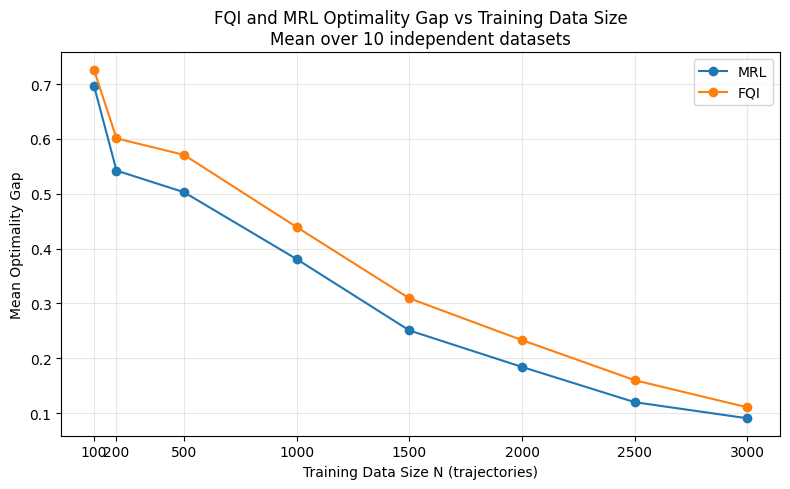

In [ ]:
# =========================================================
# Visualize the average performance of FQI and MRL as N increases.
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    Ns,
    mrl_mean_gaps,
    marker="o",
    label="MRL",
)

plt.plot(
    Ns,
    fqi_mean_gaps,
    marker="o",
    label="FQI",
)

plt.xlabel("Training Data Size N (trajectories)")
plt.ylabel("Mean Optimality Gap")
plt.title(
    "FQI and MRL Optimality Gap vs Training Data Size\n"
    f"Mean over {n_repeats} independent datasets"
)

plt.xticks(Ns)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Aggregate opt_k across all trials and plot the mean opt_k & training data size N.

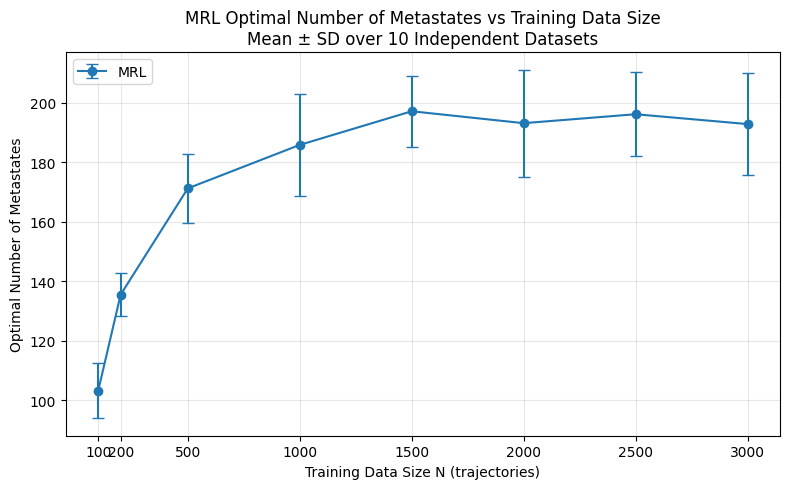

In [ ]:
# =========================================================
# A: Visualize MRL representation size as N increases
# =========================================================
plt.figure(figsize=(8, 5))

plt.errorbar(
    Ns,
    mrl_mean_opt_k,
    yerr=mrl_std_opt_k,
    marker="o",
    capsize=4,
    label="MRL",
)

plt.xlabel("Training Data Size N (trajectories)")
plt.ylabel("Optimal Number of Metastates")
plt.title(
    "MRL Optimal Number of Metastates vs Training Data Size\n"
    f"Mean ± SD over {n_repeats} Independent Datasets"
)

plt.xticks(Ns)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

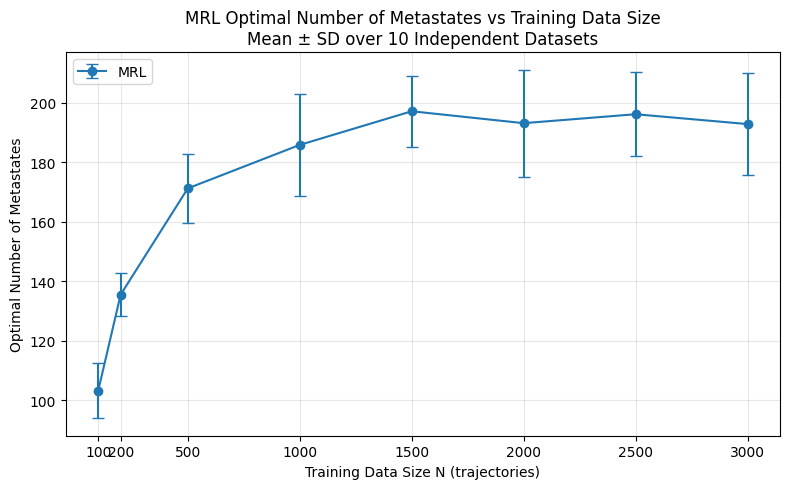

In [ ]:
# =========================================================
# B: Visualize MRL representation size as N increases
# Directly from cached results_df
# =========================================================
plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_df["N"],
    summary_df["MRL_Mean_OptK"],
    yerr=summary_df["MRL_Std_OptK"],
    marker="o",
    capsize=4,
    label="MRL",
)

plt.xlabel("Training Data Size N (trajectories)")
plt.ylabel("Optimal Number of Metastates")

plt.title(
    "MRL Optimal Number of Metastates vs Training Data Size\n"
    f"Mean ± SD over {results_df['Repeat'].nunique()} Independent Datasets"
)

plt.xticks(summary_df["N"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Optimality Gap & th (10 Trials )

The parameter `th` controls the stopping criterion of stochastic MRL. Transition heterogeneity is measured using the standard deviation of the estimated transition probabilities, with `th` serving as an empirical proxy for the theoretical coherence parameter $\gamma$. A smaller `th` imposes a stricter coherence requirement and generally leads to more state splitting.

For each independent trial, a dataset containing `N = 1000` trajectories is generated. 5 MRL models with different `th` values are then fitted on the same dataset while all other settings are held constant. The entire experiment is repeated 10 times using different random seeds. For each `th`, the optimality gap and the selected number of metastates (`MRL_OptK`) are summarized across the 10 trials.

In [ ]:
# =========================================================
# Sensitivity analysis: stochastic heterogeneity threshold
# =========================================================
n_repeats = 10
N_fixed = 1000

th_values = [
    0.10,
    0.11,
    0.12,
    0.13,
    0.14,
]

max_num_steps = 20
p_diabetes = 0.2

nS = State.NUM_OBS_STATES
nA = Action.NUM_ACTIONS_TOTAL

random_policy = (
    np.ones((nS, nA)) / nA
)

In [ ]:
# =========================================================
# Evaluation settings
# =========================================================
gamma_eval = 0.99
num_eval_rollouts = 5000

true_pi_dg = true_pi[:nS]

true_policy_array = deterministic_pi_to_prob_array(
    true_pi_dg,
    num_actions=nA,
)

V_true, true_returns = estimate_policy_value(
    policy_array=true_policy_array,
    num_iters=num_eval_rollouts,
    max_num_steps=max_num_steps,
    gamma=gamma_eval,
    policy_idx_type="obs",
    output_state_idx_type="obs",
    p_diabetes=p_diabetes,
    use_tqdm=True,
    tqdm_desc="True optimal policy",
)

print("Estimated V_true:", V_true)

True optimal policy:   0%|          | 0/5000 [00:00<?, ?it/s]

Estimated V_true: 0.19963189433935533


In [ ]:
# =========================================================
# MRL parameters
# =========================================================
pfeatures = 7
h = 5
gamma_mrl = 0.99

max_k = 200
distance_threshold = 0.5

precision_thresh = 1e-14

classification = "DecisionTreeClassifier"
split_classifier_params_base = {
    "max_depth": 2,
}

clustering = "Agglomerative"

eval_samples = None
stochastic = True

In [ ]:
# =========================================================
# Result matrices
# rows    = independent datasets
# columns = different th values
# =========================================================
mrl_gap_matrix = np.full(
    (n_repeats, len(th_values)),
    np.nan,
    dtype=float,
)

mrl_opt_k_matrix = np.full(
    (n_repeats, len(th_values)),
    np.nan,
    dtype=float,
)

In [ ]:
# =========================================================
# Outer loop: 10 independently generated N=1000 datasets
# =========================================================
for repeat_idx in range(n_repeats):

    data_seed = repeat_idx

    np.random.seed(data_seed)
    random.seed(data_seed)

    print("\n" + "=" * 80)
    print(
        f"Independent experiment "
        f"{repeat_idx + 1}/{n_repeats}, "
        f"data seed={data_seed}"
    )
    print("=" * 80)

    # -----------------------------------------------------
    # 1. Generate one fixed N=1000 dataset
    # -----------------------------------------------------
    dg_repeat = DataGenerator()

    (
        iter_states,
        iter_actions,
        iter_lengths,
        iter_rewards,
        iter_component,
        emp_tx_mat,
        emp_r_mat,
    ) = dg_repeat.simulate(
        num_iters=N_fixed,
        max_num_steps=max_num_steps,
        policy=random_policy,
        policy_idx_type="obs",
        p_diabetes=p_diabetes,
        output_state_idx_type="obs",
        use_tqdm=True,
        tqdm_desc=(
            f"Generating dataset "
            f"{repeat_idx + 1}/{n_repeats}"
        ),
    )

    df_mrl = dg_to_df_mrl(
        iter_states=iter_states,
        iter_actions=iter_actions,
        iter_lengths=iter_lengths,
        iter_rewards=iter_rewards,
        iter_component=iter_component,
    )

    assert df_mrl["ID"].nunique() == N_fixed

    # =====================================================
    # 2. Fit one MRL model for each th on SAME dataset
    # =====================================================
    models = []

    for th_idx, th in enumerate(th_values):

        print("\n" + "-" * 70)
        print(
            f"Repeat={repeat_idx + 1}, "
            f"N={N_fixed}, "
            f"th={th}"
        )
        print("-" * 70)

        model_seed = repeat_idx

        split_classifier_params = {
            **split_classifier_params_base,
            "random_state": model_seed,
        }

        m_th = MDP_model()

        m_th.fit(
            data=df_mrl.copy(),
            pfeatures=pfeatures,
            h=h,
            gamma=gamma_mrl,
            max_k=max_k,
            distance_threshold=distance_threshold,
            th=th,
            precision_thresh=precision_thresh,
            classification=classification,
            split_classifier_params=split_classifier_params,
            clustering=clustering,
            random_state=model_seed,
            plot=False,
            eval_samples=eval_samples,
            stochastic=True,
        )

        models.append(m_th)

        # Save optimal number of metastates
        mrl_opt_k_matrix[
            repeat_idx,
            th_idx,
        ] = getattr(
            m_th,
            "opt_k",
            np.nan,
        )

    # =====================================================
    # 3. Evaluate all five th models
    #    IMPORTANT: outside the th loop
    # =====================================================
    print(
        f"\nEvaluating {len(models)} MRL models "
        f"from repeat {repeat_idx + 1}"
    )

    mrl_gaps = value_diff(
        models=models,
        baseline_pi=true_pi_dg,
        num_states=nS,
        num_iters=num_eval_rollouts,
        max_num_steps=max_num_steps,
        idx_type="obs",
        diabetic_idx=0,
        gamma=gamma_eval,
        min_action_obs=1,
        epsilon=1e-4,
        p_diabetes=p_diabetes,
        use_median=False,
        use_tqdm=True,
    )

    mrl_gaps = np.asarray(
        mrl_gaps,
        dtype=float,
    )

    if len(mrl_gaps) != len(th_values):
        raise ValueError(
            "value_diff returned an unexpected number "
            "of gaps: "
            f"expected {len(th_values)}, "
            f"got {len(mrl_gaps)}"
        )

    mrl_gap_matrix[
        repeat_idx,
        :,
    ] = mrl_gaps

    # =====================================================
    # 4. Print results for this repeat
    # =====================================================
    print("\nResults for this repeat:")

    for th_idx, th in enumerate(th_values):

        print(
            f"th={th}: "
            f"gap={mrl_gap_matrix[repeat_idx, th_idx]:.6f}, "
            f"opt_k={mrl_opt_k_matrix[repeat_idx, th_idx]:.0f}"
        )

    # =====================================================
    # 5. Clean up AFTER all five models are evaluated
    # =====================================================
    del (
        iter_states,
        iter_actions,
        iter_lengths,
        iter_rewards,
        iter_component,
        emp_tx_mat,
        emp_r_mat,
        df_mrl,
        models,
    )

    gc.collect()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# =========================================================
# Raw results
# =========================================================
result_rows = []

for repeat_idx in range(n_repeats):

    for th_idx, th in enumerate(th_values):

        result_rows.append(
            {
                "Repeat": repeat_idx + 1,
                "N": N_fixed,
                "th": th,
                "MRL_Gap": mrl_gap_matrix[
                    repeat_idx,
                    th_idx,
                ],
                "MRL_OptK": mrl_opt_k_matrix[
                    repeat_idx,
                    th_idx,
                ],
            }
        )

results_th_df = pd.DataFrame(
    result_rows
)

display(results_th_df)

,Repeat,N,th,MRL_Gap,MRL_OptK
0,1,1000,0.10,0.380218,140.0
1,1,1000,0.11,0.345477,131.0
2,1,1000,0.12,0.335415,123.0
3,1,1000,0.13,0.268676,113.0
4,1,1000,0.14,0.641357,64.0
5,2,1000,0.10,0.359712,145.0
6,2,1000,0.11,0.354089,144.0
7,2,1000,0.12,0.517970,128.0
8,2,1000,0.13,0.521308,123.0
9,2,1000,0.14,0.534068,99.0


In [ ]:
# Cache the results table (reduce computation time)
results_th_df.to_pickle(
    os.path.join(cache_dir, "optimalityGap_th_result_df.pkl")
)

In [ ]:
# Read the results table (reduce computation time)
results_th_df = pd.read_pickle(
    os.path.join(cache_dir, "optimalityGap_th_result_df.pkl")
)


In [ ]:
# =========================================================
# Summarize sensitivity to th
# =========================================================
mrl_mean_gaps = np.nanmean(
    mrl_gap_matrix,
    axis=0,
)

mrl_std_gaps = np.nanstd(
    mrl_gap_matrix,
    axis=0,
    ddof=1,
)

opt_k_mean = np.nanmean(
    mrl_opt_k_matrix,
    axis=0,
)

opt_k_std = np.nanstd(
    mrl_opt_k_matrix,
    axis=0,
    ddof=1,
)

summary_th_df = pd.DataFrame(
    {
        "th": th_values,
        "Mean_Optimality_Gap": mrl_mean_gaps,
        "SD_Optimality_Gap": mrl_std_gaps,
        "Mean_OptK": opt_k_mean,
        "SD_OptK": opt_k_std,
    }
)

display(summary_th_df)

,th,Mean_Optimality_Gap,SD_Optimality_Gap,Mean_OptK,SD_OptK
0,0.10,0.411427,0.118421,143.6,9.845473
1,0.11,0.371577,0.094372,125.2,28.835934
2,0.12,0.415922,0.099709,113.6,23.310465
3,0.13,0.398159,0.085184,104.9,22.951398
4,0.14,0.426226,0.115964,89.7,20.640037


In [ ]:
# =========================================================
# Summarize sensitivity to th
# Directly from cached results_th_df
# =========================================================
summary_th_df = (
    results_th_df
    .groupby("th")
    .agg(
        Mean_Optimality_Gap=("MRL_Gap", "mean"),
        SD_Optimality_Gap=("MRL_Gap", "std"),
        Mean_OptK=("MRL_OptK", "mean"),
        SD_OptK=("MRL_OptK", "std"),
    )
    .reset_index()
    .sort_values("th")
    .reset_index(drop=True)
)

display(summary_th_df)

,th,Mean_Optimality_Gap,SD_Optimality_Gap,Mean_OptK,SD_OptK
0,0.10,0.411427,0.118421,143.6,9.845473
1,0.11,0.371577,0.094372,125.2,28.835934
2,0.12,0.415922,0.099709,113.6,23.310465
3,0.13,0.398159,0.085184,104.9,22.951398
4,0.14,0.426226,0.115964,89.7,20.640037


Plot sensitivity of MRL policy performance to `th`

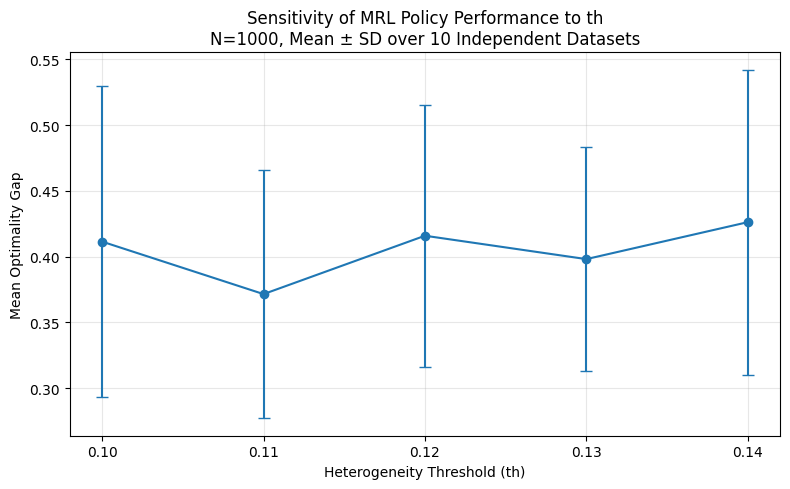

In [ ]:
# =========================================================
# Plot sensitivity of MRL policy performance to th
# =========================================================
plt.figure(figsize=(8, 5))

plt.errorbar(
    th_values,
    mrl_mean_gaps,
    yerr=mrl_std_gaps,
    marker="o",
    capsize=4,
)

plt.xlabel("Heterogeneity Threshold (th)")
plt.ylabel("Mean Optimality Gap")
plt.title(
    "Sensitivity of MRL Policy Performance to th\n"
    f"N={N_fixed}, Mean ± SD over "
    f"{n_repeats} Independent Datasets"
)

plt.xticks(th_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

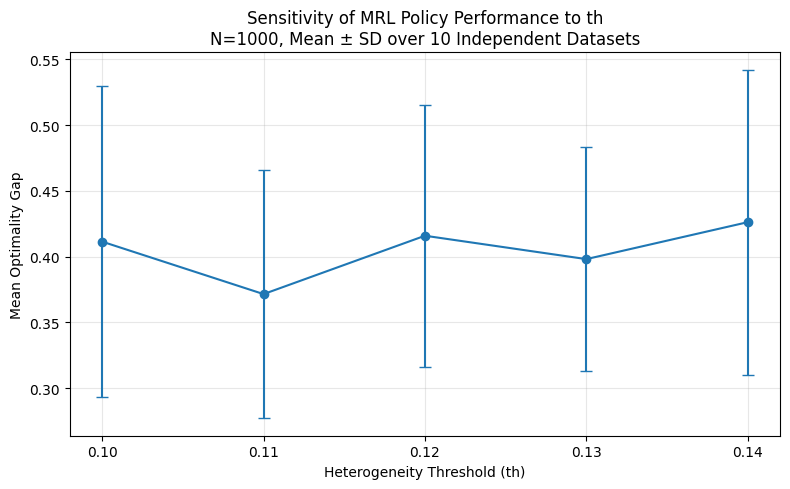

In [ ]:
# =========================================================
# Plot sensitivity of MRL policy performance to th
# Directly from cached results_th_df
# =========================================================
n_repeats_cached = results_th_df["Repeat"].nunique()
N_fixed_cached = results_th_df["N"].iloc[0]

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_th_df["th"],
    summary_th_df["Mean_Optimality_Gap"],
    yerr=summary_th_df["SD_Optimality_Gap"],
    marker="o",
    capsize=4,
)

plt.xlabel("Heterogeneity Threshold (th)")
plt.ylabel("Mean Optimality Gap")

plt.title(
    "Sensitivity of MRL Policy Performance to th\n"
    f"N={N_fixed_cached}, Mean ± SD over "
    f"{n_repeats_cached} Independent Datasets"
)

plt.xticks(summary_th_df["th"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

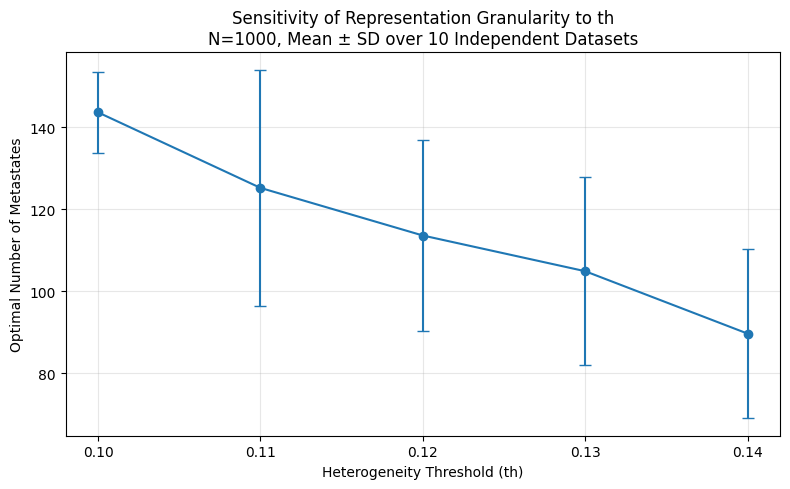

In [ ]:
# =========================================================
# Plot sensitivity of representation granularity to th
# =========================================================
plt.figure(figsize=(8, 5))

plt.errorbar(
    th_values,
    opt_k_mean,
    yerr=opt_k_std,
    marker="o",
    capsize=4,
)

plt.xlabel("Heterogeneity Threshold (th)")
plt.ylabel("Optimal Number of Metastates")
plt.title(
    "Sensitivity of Representation Granularity to th\n"
    f"N={N_fixed}, Mean ± SD over "
    f"{n_repeats} Independent Datasets"
)

plt.xticks(th_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

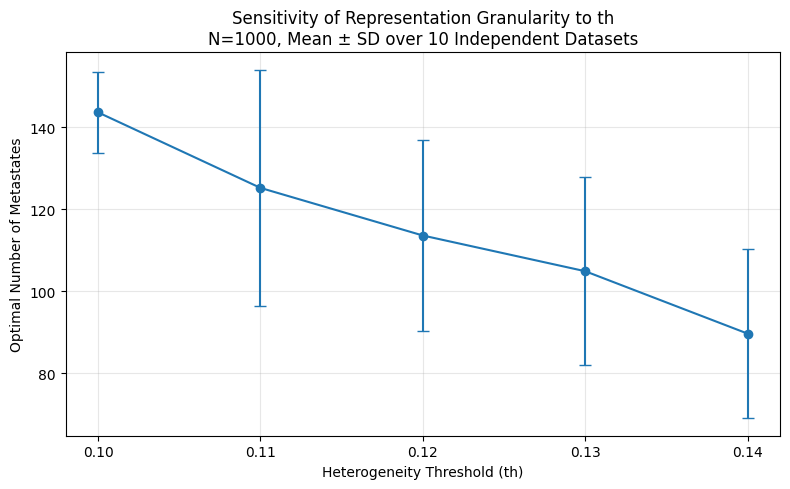

In [ ]:
# =========================================================
# Plot sensitivity of representation granularity to th
# Directly from cached results_th_df
# =========================================================
n_repeats_cached = results_th_df["Repeat"].nunique()
N_fixed_cached = results_th_df["N"].iloc[0]

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_th_df["th"],
    summary_th_df["Mean_OptK"],
    yerr=summary_th_df["SD_OptK"],
    marker="o",
    capsize=4,
)

plt.xlabel("Heterogeneity Threshold (th)")
plt.ylabel("Optimal Number of Metastates")

plt.title(
    "Sensitivity of Representation Granularity to th\n"
    f"N={N_fixed_cached}, Mean ± SD over "
    f"{n_repeats_cached} Independent Datasets"
)

plt.xticks(summary_th_df["th"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretability

Clinical Interpretability of Learned MRL Clusters

In [12]:
feature_names = {
    "FEATURE_0": "Heart Rate",
    "FEATURE_1": "Systolic BP",
    "FEATURE_2": "Oxygen Saturation",
    "FEATURE_3": "Glucose",
    "FEATURE_4": "Antibiotics",
    "FEATURE_5": "Vasopressors",
    "FEATURE_6": "Ventilation",
}

feature_cols = [
    f"FEATURE_{i}"
    for i in range(7)
]

### Cluster Interpretability

Evaluate whether the metastates learned by MRL can be directly characterized using observable clinical variables.

Unlike black-box state representations, MRL produces explicit discrete metastates whose composition can be inspected and described in terms of patient physiological conditions and treatment status.

Representative visualization:
- Normalized cluster feature profiles (we use the full mrl model ftom Repeat 0)
- Feature-value composition within clusters (we use the full mrl model ftom Repeat 0)

Cross-trial quantitative evaluation:  
- Within-cluster variance reduction  
- Cluster-feature NMI


#### Normalized cluster feature profiles

Visualize the mean clinical feature profile of each metastate learned in Repeat 0.

Purpose:
Show that individual MRL states can be characterized directly in terms of physiological measurements and treatment status, providing an interpretable description of the learned state space.

Distinct feature patterns across clusters indicate that the learned metastates represent different clinical configurations rather than opaque latent embeddings.

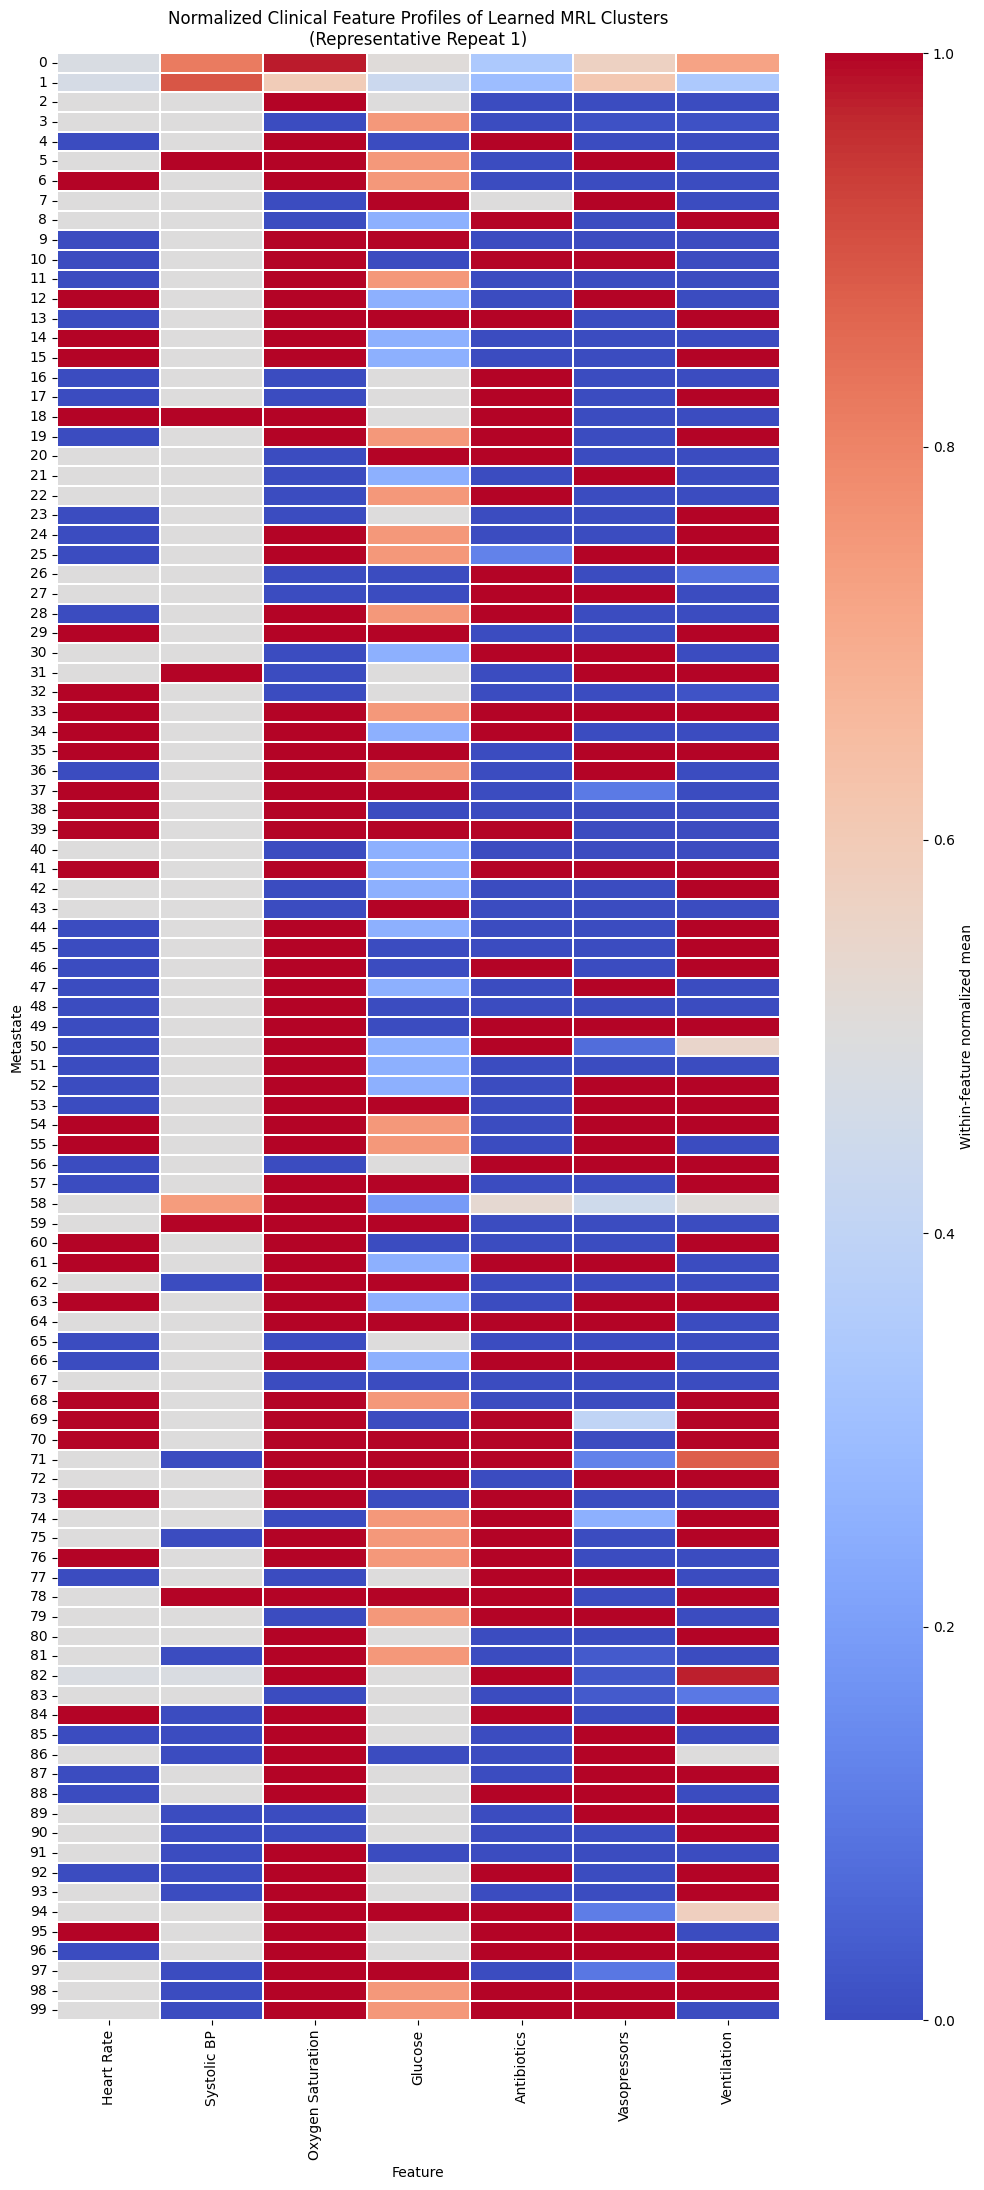

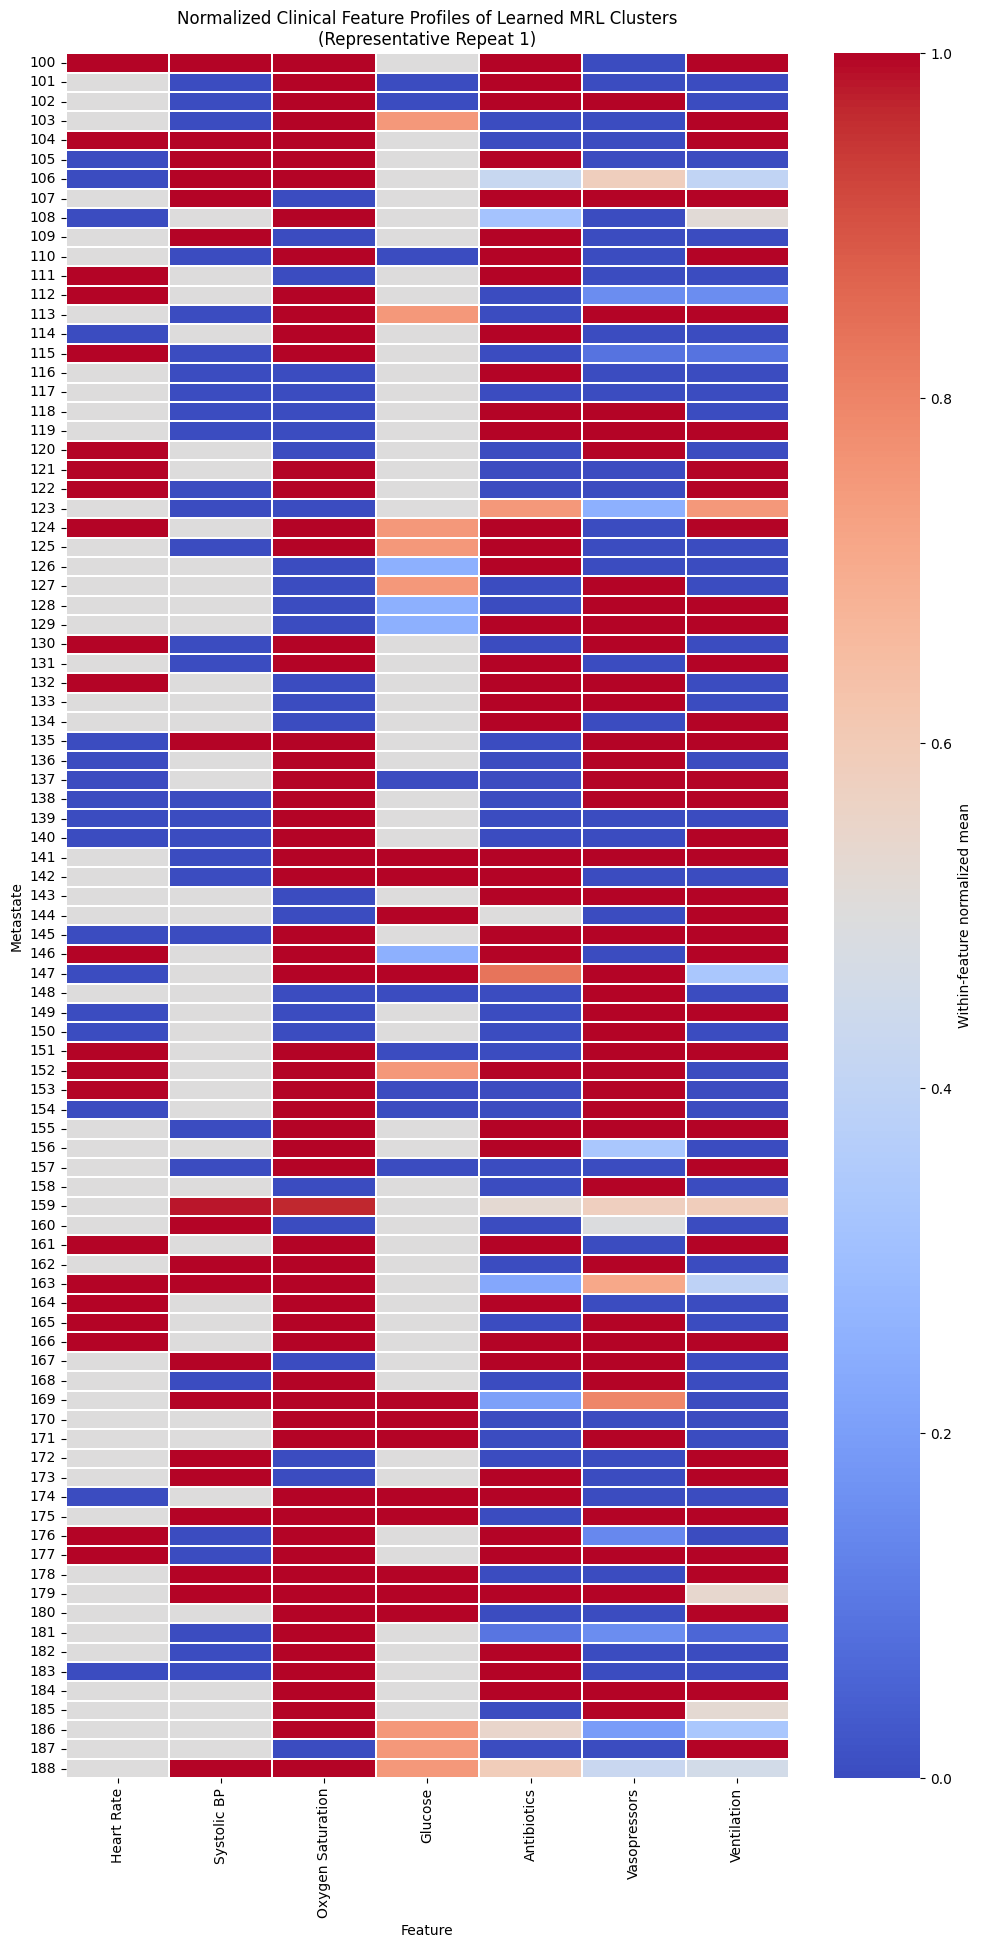

In [13]:
# ============================================================
# Load representative MRL model from cache: Repeat 1, N = 3000
# ============================================================

representative_repeat = 1
representative_N = 3000

model_path = (
    f"cache/mrl_models/"
    f"mrl_repeat{representative_repeat:02d}_N{representative_N}.pkl"
)

with open(model_path, "rb") as f:
    m_rep = pkl.load(f)

df_cluster_rep = (
    m_rep.df_trained.copy()
)

# Mean value of each clinical feature within each cluster
cluster_feature_mean = (
    df_cluster_rep
    .groupby("CLUSTER")[feature_cols]
    .mean()
    .sort_index()
)

# Normalize each feature independently across clusters
# so features with different categorical ranges can share
# the same heatmap color scale.
column_min = (
    cluster_feature_mean
    .min(axis=0)
)

column_max = (
    cluster_feature_mean
    .max(axis=0)
)

column_range = (
    column_max - column_min
).replace(0, 1)

cluster_feature_mean_scaled = (
    cluster_feature_mean
    - column_min
) / column_range

cluster_feature_mean_scaled_named = (
    cluster_feature_mean_scaled
    .rename(columns=feature_names)
)

# ============================================================
# Split the normalized feature profiles into two figures
# Figure 1: clusters 0–99
# Figure 2: clusters 100 and above
# ============================================================

cluster_profiles_0_99 = (
    cluster_feature_mean_scaled_named.loc[
        cluster_feature_mean_scaled_named.index < 100
    ]
)

cluster_profiles_100_plus = (
    cluster_feature_mean_scaled_named.loc[
        cluster_feature_mean_scaled_named.index >= 100
    ]
)


def plot_cluster_profiles(
    data,
    output_path=None,
):
    fig, ax = plt.subplots(
        figsize=(
            10,
            max(
                6,
                0.22 * len(data),
            ),
        )
    )

    sns.heatmap(
        data,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        linewidths=0.15,
        linecolor="white",
        cbar_kws={
            "label": "Within-feature normalized mean",
        },
        ax=ax,
    )

    ax.set_xlabel("Feature")
    ax.set_ylabel("Metastate")

    plt.title( "Normalized Clinical Feature Profiles " "of Learned MRL Clusters\n" f"(Representative Repeat {representative_repeat})" )

    # No internal title because the LaTeX caption provides it
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)


# Metastates 0–99
plot_cluster_profiles(
    cluster_profiles_0_99,
    output_path=(
        "normalized_cluster_feature_profiles_0_99.pdf"
    ),
)

# Metastates 100 and above
plot_cluster_profiles(
    cluster_profiles_100_plus,
    output_path=(
        "normalized_cluster_feature_profiles_100_plus.pdf"
    ),
)

#### Feature-value composition within clusters

Visualize the full categorical distribution of each clinical feature within every metastate in Repeat 0.

Purpose:
Examine the internal feature composition of each metastate and identify whether clusters correspond to clinically homogeneous patient groups.

Concentrated distributions make the clinical meaning of a metastate easier to interpret, while mixed distributions reveal which features remain heterogeneous within a state.

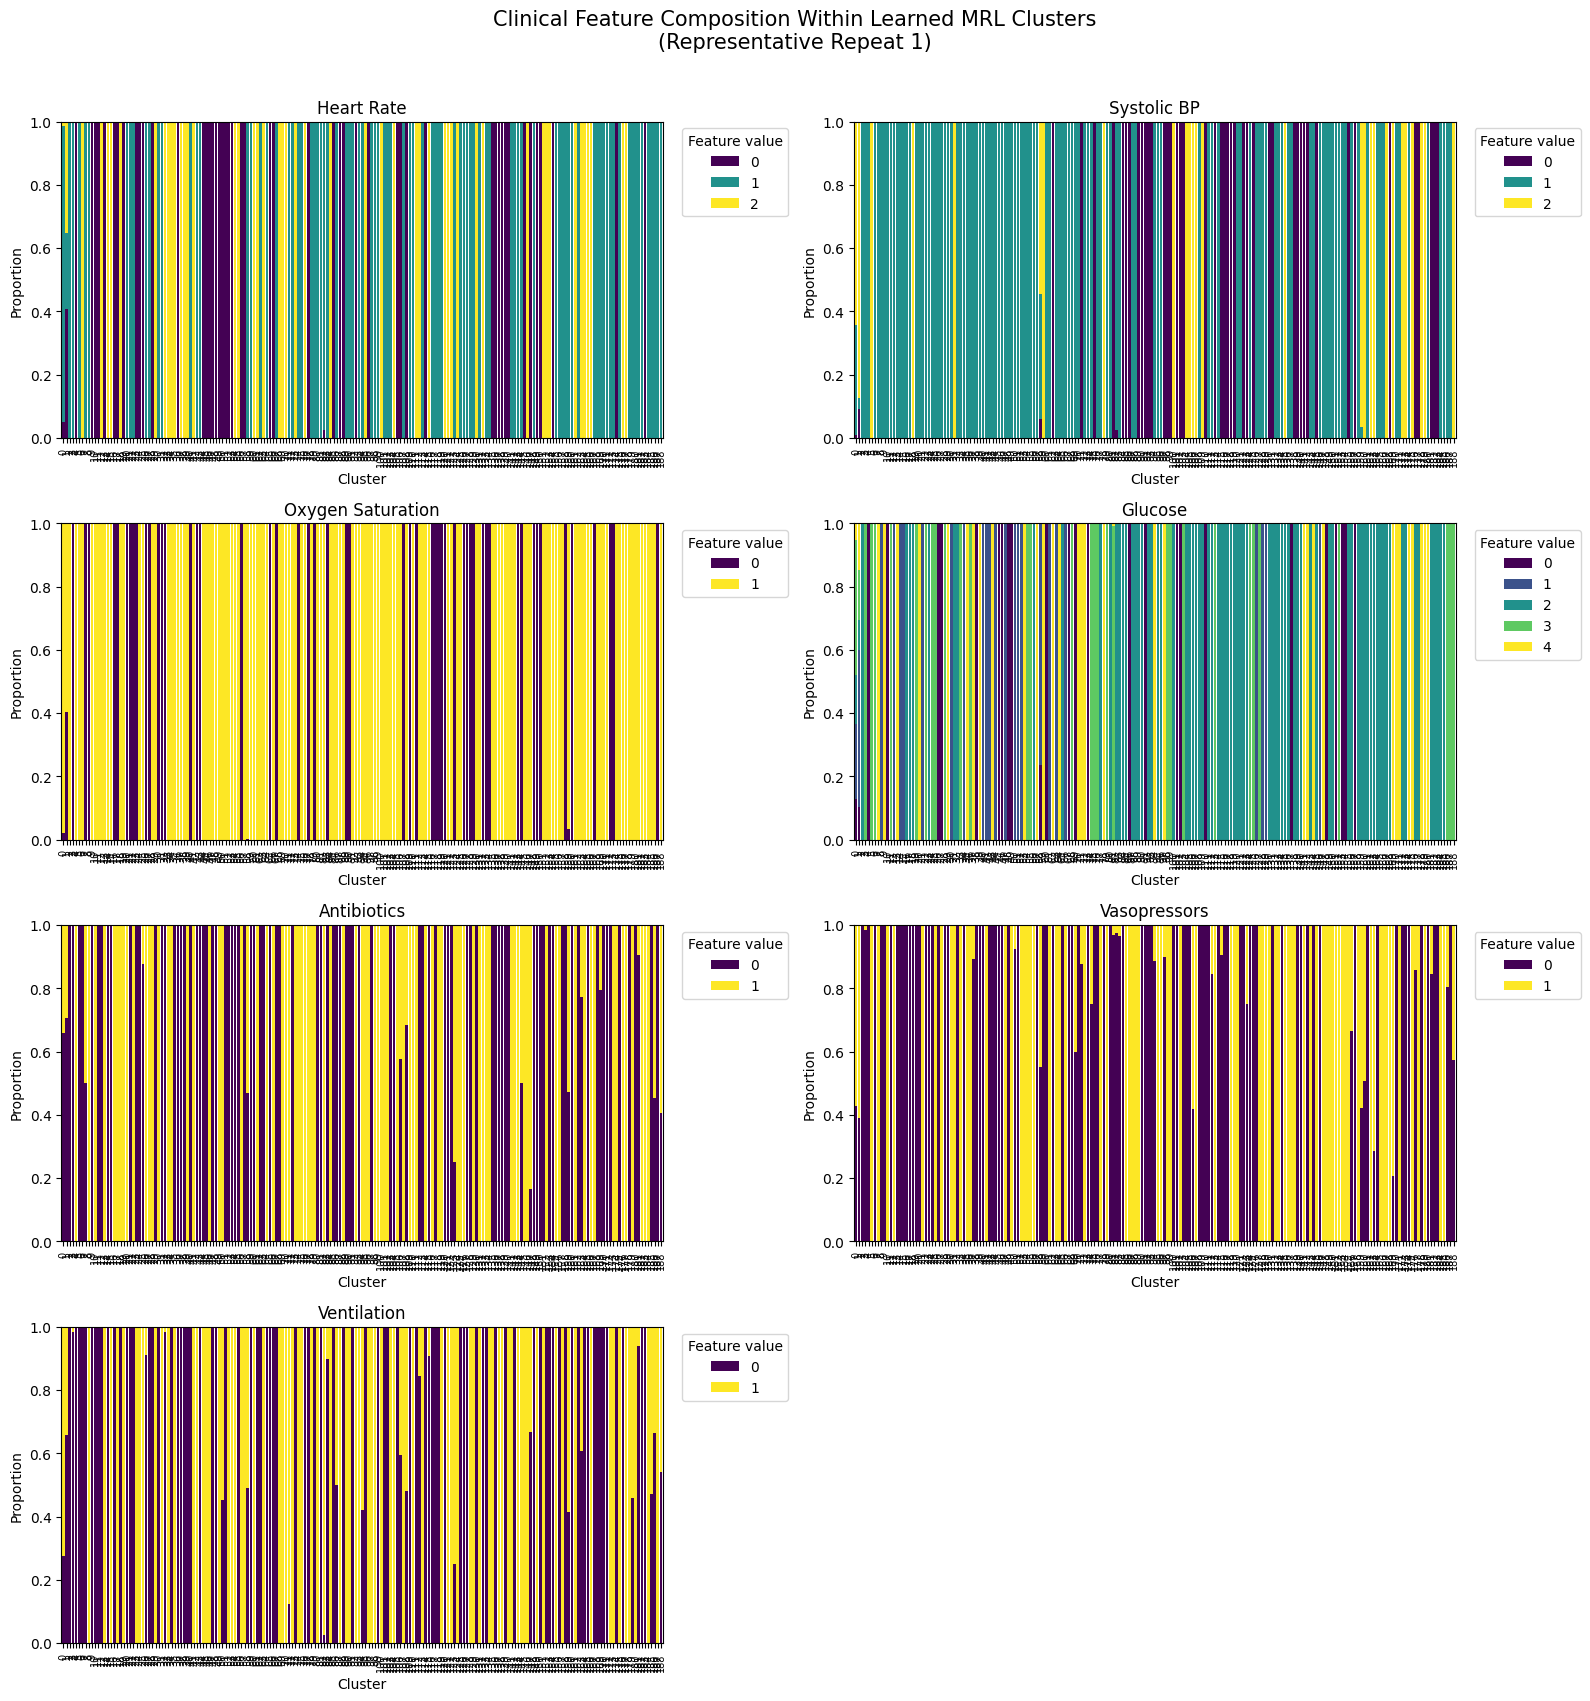

In [ ]:
def plot_feature_value_composition(
    df,
    feature_cols,
    feature_names,
    cluster_col="CLUSTER",
    ncols=2,
):

    n_features = len(feature_cols)

    nrows = int(
        np.ceil(
            n_features / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            16,
            4.2 * nrows,
        ),
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, feature in zip(
        axes,
        feature_cols,
    ):

        # Distribution P(feature value | cluster)
        composition = (
            df
            .groupby(cluster_col)[feature]
            .value_counts(normalize=True)
            .unstack(fill_value=0)
            .sort_index()
        )

        # Keep categorical feature values in numerical order
        composition = composition.reindex(
            sorted(composition.columns),
            axis=1,
        )

        composition.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            width=0.85,
            colormap="viridis",
        )

        ax.set_title(
            feature_names[feature]
        )

        ax.set_xlabel("Cluster")
        ax.set_ylabel("Proportion")
        ax.set_ylim(0, 1)

        ax.legend(
            title="Feature value",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )

        ax.tick_params(
            axis="x",
            labelrotation=90,
            labelsize=7,
        )

    # Remove unused subplot
    for ax in axes[n_features:]:
        ax.remove()

    fig.suptitle(
        "Clinical Feature Composition "
        "Within Learned MRL Clusters\n"
        f"(Representative Repeat {representative_repeat})",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()


plot_feature_value_composition(
    df=df_cluster_rep,
    feature_cols=feature_cols,
    feature_names=feature_names,
)

#### Within-cluster variance reduction

Measure how much variability in each clinical feature is reduced after conditioning on the learned MRL metastates.

Purpose:
Quantify whether MRL consistently groups observations with similar clinical characteristics.

Higher variance reduction indicates that the learned state representation forms more internally homogeneous clinical subgroups. Results are summarized as mean ± SD across all independent repeats.

In [14]:
# ============================================================
# Within-cluster variance reduction
#
# Evaluate the N = 3000 MRL model from each independent repeat.
# Models are loaded from cache/mrl_models.
# ============================================================

variance_reduction_trials = []

representative_N = 3000
n_repeats = 10


for repeat in range(1, n_repeats + 1):

    # 1. Load the N = 3000 MRL model for this repeat
    model_path = (
        f"cache/mrl_models/"
        f"mrl_repeat{repeat:02d}_N{representative_N}.pkl"
    )

    with open(model_path, "rb") as f:
        model = pkl.load(f)


    df_cluster = (
        model.df_trained.copy()
    )

    # 2. Number of observations in each cluster
    cluster_sizes = (
        df_cluster
        .groupby("CLUSTER")
        .size()
    )

    # Weight each cluster according to its sample size
    cluster_weights = (
        cluster_sizes
        / cluster_sizes.sum()
    )


    # 3. Variance of each feature within each cluster
    cluster_feature_variance = (
        df_cluster
        .groupby("CLUSTER")[feature_cols]
        .var(ddof=1)
        .fillna(0.0)
    )


    # 4. Overall variance of each feature
    global_feature_variance = (
        df_cluster[feature_cols]
        .var(ddof=1)
    )


    # 5. Weighted average within-cluster variance
    weighted_within_variance = (
        cluster_feature_variance
        .mul(
            cluster_weights,
            axis=0,
        )
        .sum(axis=0)
    )


    # 6. Variance reduction (1 - weighted within-cluster variance / global variance)
    variance_ratio = (
        weighted_within_variance
        .div(
            global_feature_variance
            .replace(0, np.nan)
        )
    )

    variance_reduction = (
        1 - variance_ratio
    )


    # 7. Store results for this repeat
    trial_result = (
        variance_reduction
        .rename(feature_names)
        .to_dict()
    )

    trial_result[
        "Repeat"
    ] = repeat

    variance_reduction_trials.append(
        trial_result
    )


# ============================================================
# Results
# ============================================================

variance_reduction_trials = (
    pd.DataFrame(
        variance_reduction_trials
    )
    .set_index("Repeat")
)


print(
    "=== Variance reduction: "
    "trial-level results (N = 3000) ==="
)

display(
    variance_reduction_trials.round(4)
)


# ============================================================
# Mean ± SD across repeats
# ============================================================

variance_reduction_summary = pd.DataFrame(
    {
        "Mean": (
            variance_reduction_trials
            .mean(axis=0)
        ),
        "Std": (
            variance_reduction_trials
            .std(axis=0, ddof=1)
        ),
    }
)


variance_reduction_summary = (
    variance_reduction_summary
    .sort_values(
        "Mean",
        ascending=False,
    )
)


print(
    "\n=== Variance reduction: "
    "mean ± SD across repeats (N = 3000) ==="
)

display(
    variance_reduction_summary.round(4)
)

=== Variance reduction: trial-level results (N = 3000) ===


,Heart Rate,Systolic BP,Oxygen Saturation,Glucose,Antibiotics,Vasopressors,Ventilation
Repeat,,,,,,,
1,0.7800,0.6677,0.7153,0.8102,0.3901,0.3614,0.3295
2,0.7767,0.6639,0.7419,0.8130,0.2883,0.3262,0.2648
3,0.7625,0.8675,0.5680,0.8543,0.4867,0.3840,0.3310
4,0.7834,0.9128,0.6859,0.8418,0.3635,0.4089,0.3087
5,0.7708,0.8182,0.7537,0.8422,0.3630,0.3534,0.3019
6,0.7684,0.9126,0.6850,0.8242,0.5561,0.4776,0.3658
7,0.5483,0.6540,0.7618,0.7897,0.3059,0.2942,0.2621
8,0.7386,0.7949,0.7358,0.8512,0.4076,0.3967,0.2770
9,0.7684,0.6978,0.5122,0.8599,0.2584,0.2827,0.2098



=== Variance reduction: mean ± SD across repeats (N = 3000) ===


,Mean,Std
Glucose,0.8304,0.0229
Systolic BP,0.7755,0.1018
Heart Rate,0.7469,0.0709
Oxygen Saturation,0.6921,0.0858
Antibiotics,0.3794,0.0898
Vasopressors,0.3655,0.0572
Ventilation,0.2916,0.0448


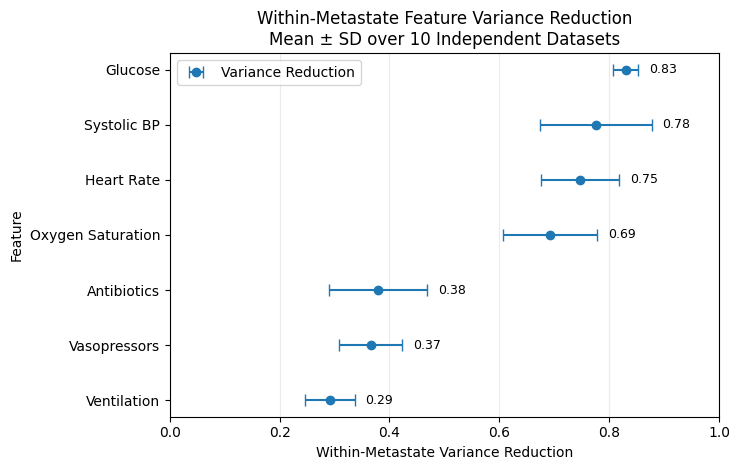

In [21]:
# ============================================================
# Plot mean within-cluster variance reduction ± SD
# ============================================================

# Sort from low to high so that the largest value appears on top
plot_df = (
    variance_reduction_summary
    .sort_values("Mean", ascending=True)
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)

ax.errorbar(
    x=plot_df["Mean"],
    y=plot_df.index,
    xerr=plot_df["Std"],
    fmt="o",
    capsize=4,
    markersize=6,
    linewidth=1.5,
    label="Variance Reduction",
)

for feature, row in plot_df.iterrows():
    ax.text(
        row["Mean"] + row["Std"] + 0.02,
        feature,
        f'{row["Mean"]:.2f}',
        va="center",
        fontsize=9,
    )

ax.set_title(
    "Within-Metastate Feature Variance Reduction\n"
    "Mean ± SD over 10 Independent Datasets"
)

ax.set_xlabel(
    "Within-Metastate Variance Reduction"
)

ax.set_ylabel(
    "Feature"
)

ax.set_xlim(
    0,
    1,
)

ax.legend(loc="upper left")

ax.grid(
    axis="x",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

#### Cluster-Feature NMI

Measure the normalized mutual information (NMI) between learned metastate assignments and each observed clinical feature across independent trials.

Purpose:
Quantify how much information about each clinical variable is retained in the discrete MRL representation.

Higher NMI indicates a stronger association between a feature and the learned state structure. Because NMI is invariant to cluster-label permutations, it can be summarized across independent MRL runs as mean ± SD.

In [16]:
# ============================================================
# Cluster-feature NMI
#
# Evaluate the N = 3000 MRL model from each independent repeat.
# Models are loaded from cache/mrl_models.
# ============================================================
feature_nmi_trials = []

representative_N = 3000
n_repeats = 10


for repeat in range(1, n_repeats + 1):

    # 1. Load the N = 3000 MRL model for this repeat
    model_path = (
        f"cache/mrl_models/"
        f"mrl_repeat{repeat:02d}_N{representative_N}.pkl"
    )

    with open(model_path, "rb") as f:
        model = pkl.load(f)


    df_cluster = (
        model.df_trained.copy()
    )


    # 2. Calculate cluster-feature NMI
    trial_result = {
        "Repeat": repeat
    }

    for feature in feature_cols:

        trial_result[
            feature_names[feature]
        ] = normalized_mutual_info_score(
            df_cluster["CLUSTER"],
            df_cluster[feature],
        )

    feature_nmi_trials.append(
        trial_result
    )


# ============================================================
# Results
# ============================================================

feature_nmi_trials = (
    pd.DataFrame(
        feature_nmi_trials
    )
    .set_index("Repeat")
)


print(
    "=== Cluster-feature NMI: "
    "trial-level results (N = 3000) ==="
)

display(
    feature_nmi_trials.round(4)
)


# ============================================================
# Mean ± SD across repeats
# ============================================================

feature_nmi_summary = pd.DataFrame(
    {
        "Mean": (
            feature_nmi_trials
            .mean(axis=0)
        ),
        "Std": (
            feature_nmi_trials
            .std(axis=0, ddof=1)
        ),
    }
)


feature_nmi_summary = (
    feature_nmi_summary
    .sort_values(
        "Mean",
        ascending=False,
    )
)


print(
    "\n=== Cluster-feature NMI: "
    "mean ± SD across repeats (N = 3000) ==="
)

display(
    feature_nmi_summary.round(4)
)

=== Cluster-feature NMI: trial-level results (N = 3000) ===


,Heart Rate,Systolic BP,Oxygen Saturation,Glucose,Antibiotics,Vasopressors,Ventilation
Repeat,,,,,,,
1,0.3375,0.2790,0.1262,0.4616,0.1284,0.1170,0.1078
2,0.3556,0.2951,0.1386,0.4700,0.0973,0.1090,0.0914
3,0.3033,0.3338,0.0942,0.4812,0.1410,0.1110,0.0984
4,0.3244,0.3675,0.1112,0.4795,0.1095,0.1190,0.0940
5,0.3220,0.3241,0.1245,0.5004,0.1100,0.1073,0.0935
6,0.2972,0.3429,0.1043,0.4633,0.1568,0.1327,0.1046
7,0.2598,0.2877,0.1451,0.4496,0.1056,0.0992,0.0891
8,0.3099,0.3048,0.1237,0.4913,0.1246,0.1181,0.0848
9,0.3496,0.2988,0.0999,0.5333,0.0840,0.0896,0.0703



=== Cluster-feature NMI: mean ± SD across repeats (N = 3000) ===


,Mean,Std
Glucose,0.4792,0.0244
Heart Rate,0.3197,0.0285
Systolic BP,0.3146,0.0274
Oxygen Saturation,0.1205,0.0175
Antibiotics,0.1180,0.0213
Vasopressors,0.1122,0.0120
Ventilation,0.0922,0.0106


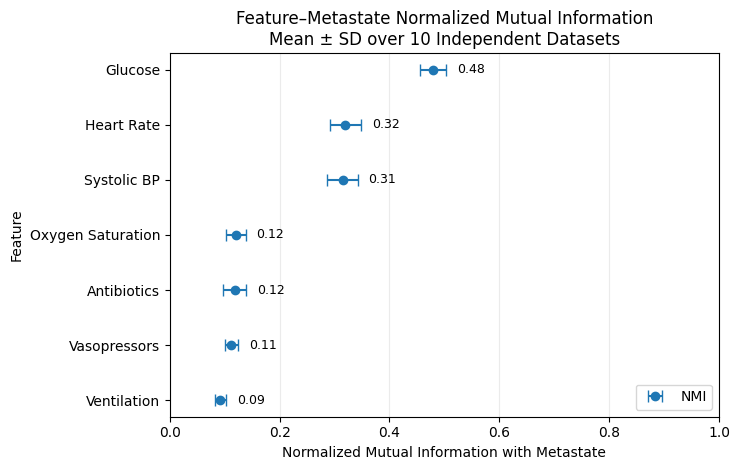

In [19]:
# ============================================================
# Plot mean cluster-feature NMI ± SD
# ============================================================

plot_df = (
    feature_nmi_summary
    .sort_values("Mean", ascending=True)
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)

ax.errorbar(
    x=plot_df["Mean"],
    y=plot_df.index,
    xerr=plot_df["Std"],
    fmt="o",
    capsize=4,
    markersize=6,
    linewidth=1.5,
    label="NMI",
)

# Add mean values
for feature, row in plot_df.iterrows():
    ax.text(
        row["Mean"] + row["Std"] + 0.02,
        feature,
        f'{row["Mean"]:.2f}',
        va="center",
        fontsize=9,
    )

ax.set_title(
    "Feature–Metastate Normalized Mutual Information\n"
    "Mean ± SD over 10 Independent Datasets"
)

ax.set_xlabel(
    "Normalized Mutual Information with Metastate"
)

ax.set_ylabel(
    "Feature"
)

ax.set_xlim(
    0,
    1,
)

ax.legend(loc="lower right")

ax.grid(
    axis="x",
    alpha=0.25,
)

plt.tight_layout()

# Save for thesis
plt.savefig(
    "cluster_feature_nmi.pdf",
    bbox_inches="tight",
)

plt.show()

### Policy Interpretability

Evaluate whether the treatment policy learned by MRL can be directly interpreted using observable clinical variables. The following analyses use the full MRL model from Repeat 0 as a representative example.

First, we compare the optimal policy learned by MRL with the simulator-derived true optimal policy over controlled two-dimensional slices of the observed state space. By varying selected physiological variables while fixing the remaining clinical features, policy maps reveal how treatment decisions change across clinically meaningful patient states and how closely these decision patterns match the true optimal policy.

Purpose:
Examine whether the decision rules produced by MRL can be directly interpreted clinically.

Two clinical features are varied at a time while all remaining features are fixed at the same reference values `normal` for both policies. This ensures that differences between the two policy maps are evaluated under identical states.

In [22]:
# =========================================================
# Reference values for fixed clinical features
#
# When 2 features are varied, the remaining 5 features
# are fixed at these values for both the true and MRL policy.
# =========================================================

fixed_values = {
    "FEATURE_0": 1,  # Normal heart rate
    "FEATURE_1": 1,  # Normal systolic blood pressure
    "FEATURE_2": 1,  # Normal oxygen saturation
    "FEATURE_3": 2,  # Normal glucose
    "FEATURE_4": 0,  # No antibiotics
    "FEATURE_5": 0,  # No vasopressors
    "FEATURE_6": 0,  # No ventilation
}

In [23]:
# =========================================================
# Compare all pairwise combinations of the four physiological
# state variables while treatment variables remain fixed.
#
# 4 features produce C(4, 2) = 6 feature pairs, with two
# policy maps per pair: true optimal policy and MRL policy.
# =========================================================

features_to_compare = [
    "FEATURE_0",  # Heart Rate
    "FEATURE_1",  # Systolic Blood Pressure
    "FEATURE_2",  # Oxygen Saturation
    "FEATURE_3",  # Glucose
]

pairs = list(
    it.combinations(
        features_to_compare,
        2,
    )
)

The resulting heatmaps show how treatment decisions change with the selected clinical variables. Agreement measures the proportion of states in each 2D slice for which MRL selects the same action as the true optimal policy.


Heart Rate × Systolic BP


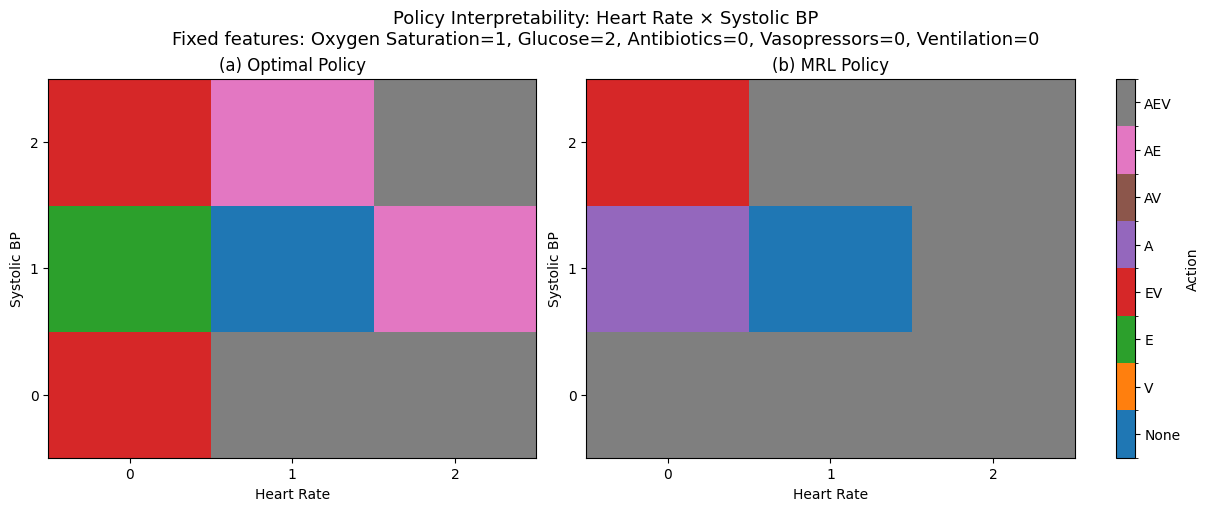


Heart Rate × Oxygen Saturation


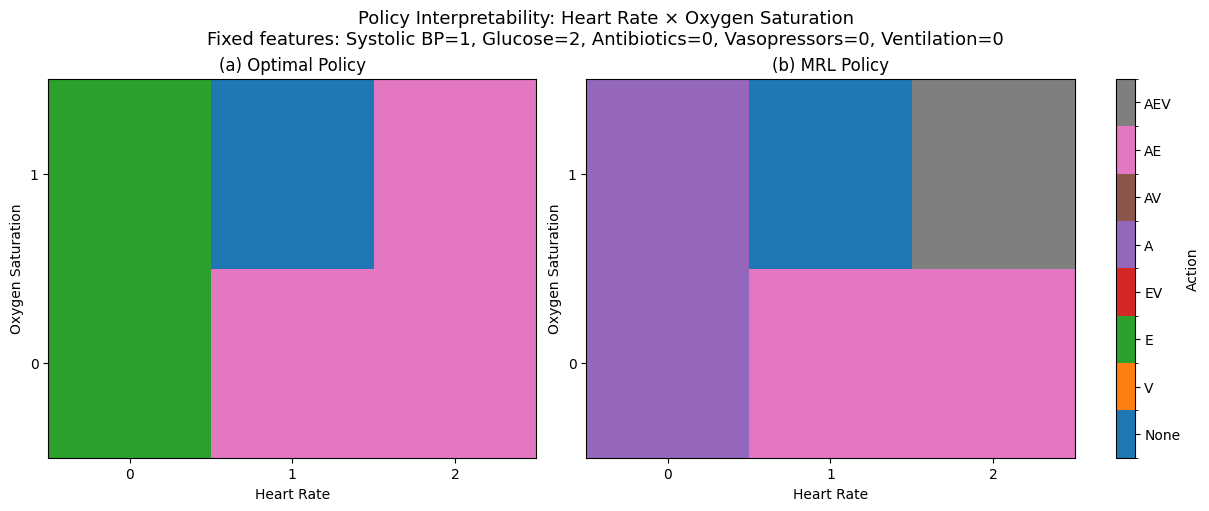


Heart Rate × Glucose


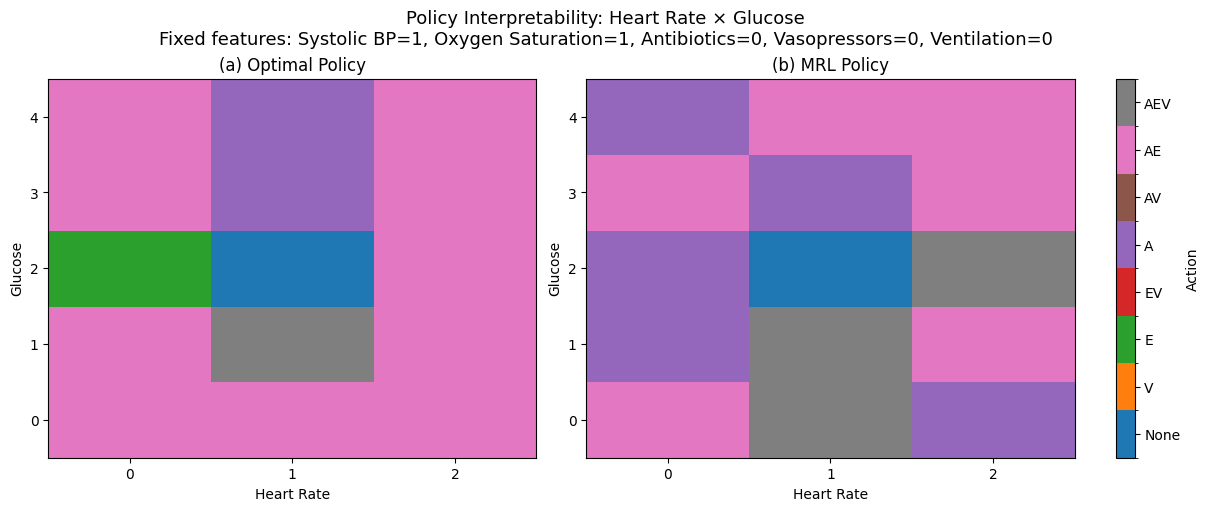


Systolic BP × Oxygen Saturation


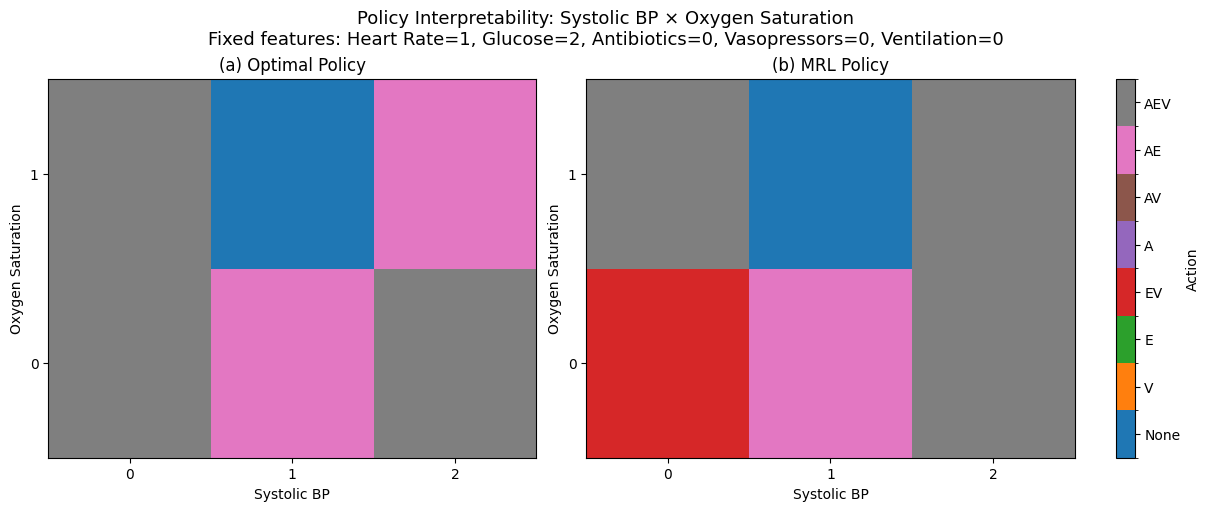


Systolic BP × Glucose


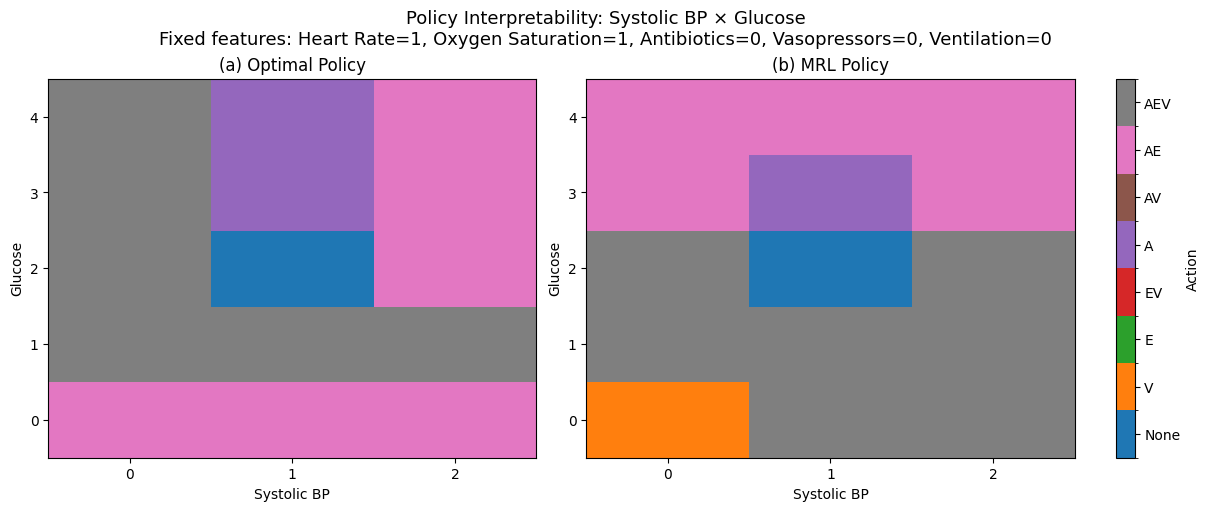


Oxygen Saturation × Glucose


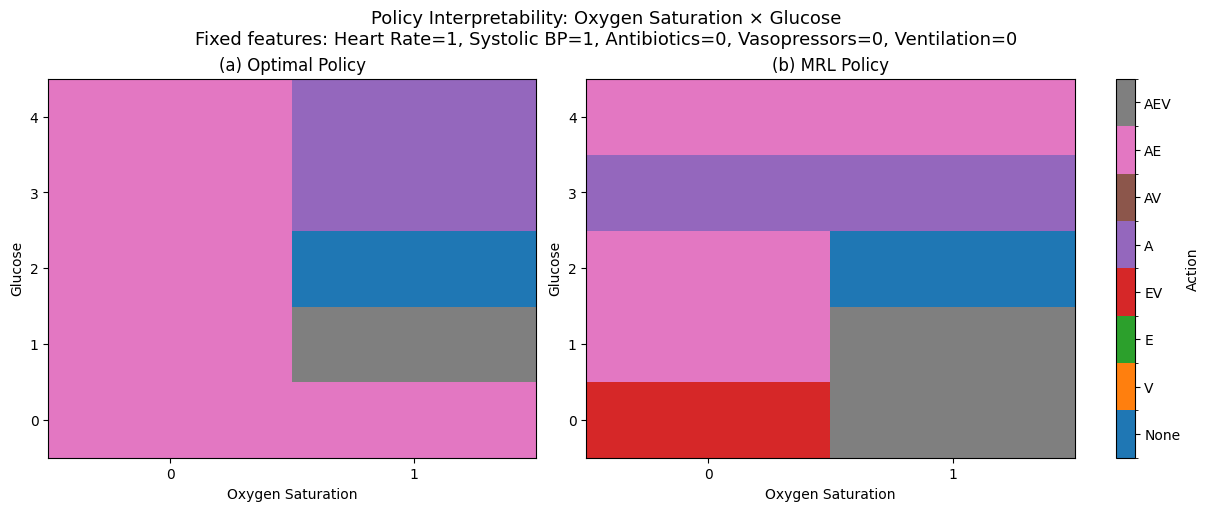

In [26]:
# ============================================================
# State-level policy interpretation
# Compare the simulator-optimal policy and the MRL policy over
# two-dimensional categorical state-space slices.
# Representative 2D policy maps: Repeat 1, N = 3000.
# ============================================================

# Load and solve representative MRL model
representative_repeat = 1
representative_N = 3000

model_path = (
    f"cache/mrl_models/"
    f"mrl_repeat{representative_repeat:02d}_N{representative_N}.pkl"
)

with open(model_path, "rb") as f:
    m_policy = pkl.load(f)

m_policy.solve_MDP(
    alpha=0.2,
    beta=0.8,
    min_action_obs=1,
    min_action_purity=0.7,
    prob="max",
    gamma=0.99,
    epsilon=1e-4,
    p=False,
)

# Complete categorical ranges of 7 features
category_values = {
    "FEATURE_0": np.array([0, 1, 2]),
    "FEATURE_1": np.array([0, 1, 2]),
    "FEATURE_2": np.array([0, 1]),
    "FEATURE_3": np.array([0, 1, 2, 3, 4]),
    "FEATURE_4": np.array([0, 1]),
    "FEATURE_5": np.array([0, 1]),
    "FEATURE_6": np.array([0, 1]),
}

# Shared discrete action color scale
cmap = ListedColormap(plt.cm.tab10.colors[:8])
norm = BoundaryNorm(np.arange(-0.5, 8.5, 1), cmap.N)

policy_results = {}

# --------------------------------------------------------
# Generate policy maps for each selected feature pair
# --------------------------------------------------------
for x_col, y_col in pairs:

    print("\n" + "=" * 70)
    print(f"{feature_names[x_col]} × {feature_names[y_col]}")

    x_values = category_values[x_col]
    y_values = category_values[y_col]


    # 1. Construct the 7-dimensional state grid
    rows = []

    for y in y_values:
        for x in x_values:
            row = fixed_values.copy()
            row[x_col] = x
            row[y_col] = y
            rows.append(row)

    grid = pd.DataFrame(rows, columns=feature_cols)


    # 2. True optimal policy
    true_actions = []

    for _, row in grid.iterrows():
        state = State(
            state_categs=[int(row[col]) for col in feature_cols],
            diabetic_idx=0,
        )
        state_idx = state.get_state_idx(idx_type="obs")
        true_actions.append(int(true_pi[state_idx]))

    true_policy = np.array(true_actions).reshape(len(y_values), len(x_values))


    # 3. MRL policy
    predicted_clusters = m_policy.m.predict(grid[feature_cols])

    mrl_actions = np.array([
        int(m_policy.pi[int(cluster)])
        for cluster in predicted_clusters
    ])

    mrl_policy = mrl_actions.reshape(len(y_values), len(x_values))


    # 4. Plot policy maps
    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5),
        constrained_layout=True,
    )

    axes[0].imshow(
        true_policy,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        extent=[
            x_values.min() - 0.5,
            x_values.max() + 0.5,
            y_values.min() - 0.5,
            y_values.max() + 0.5,
        ],
    )

    im_mrl = axes[1].imshow(
        mrl_policy,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        extent=[
            x_values.min() - 0.5,
            x_values.max() + 0.5,
            y_values.min() - 0.5,
            y_values.max() + 0.5,
        ],
    )

    axes[0].set_title("(a) Optimal Policy")
    axes[1].set_title("(b) MRL Policy")

    for ax in axes:
        ax.set_xlabel(feature_names[x_col])
        ax.set_ylabel(feature_names[y_col])
        ax.set_xticks(x_values)
        ax.set_yticks(y_values)

    # Action legend
    # A = antibiotics
    # E = mechanical ventilation
    # V = vasopressors
    action_labels = [
        "None",  # Action 0
        "V",     # Action 1
        "E",     # Action 2
        "EV",    # Action 3
        "A",     # Action 4
        "AV",    # Action 5
        "AE",    # Action 6
        "AEV",   # Action 7
    ]

    cbar = fig.colorbar(
        im_mrl,
        ax=axes,
        ticks=np.arange(8),
        fraction=0.035,
        pad=0.04,
    )

    cbar.set_ticklabels(action_labels)

    cbar.set_label("Action")


    # Display fixed feature values
    fixed_features = [
        col for col in feature_cols
        if col not in [x_col, y_col]
    ]

    fixed_text = ", ".join(
        f"{feature_names[col]}={fixed_values[col]}"
        for col in fixed_features
    )

    fig.suptitle(
        f"Policy Interpretability: {feature_names[x_col]} × {feature_names[y_col]}\n"
        f"Fixed features: {fixed_text}",
        fontsize=13,
    )

    plt.show()

    # Store results
    policy_results[(x_col, y_col)] = {
        "true": true_policy,
        "mrl": mrl_policy,
    }

In [33]:
# ============================================================
# Identify the metastate of a representative state
# ============================================================

target_state = fixed_values.copy()
target_state["FEATURE_1"] = 2   # Systolic blood pressure
target_state["FEATURE_2"] = 1   # Oxygen saturation

target_df = pd.DataFrame(
    [target_state],
    columns=feature_cols,
)

target_cluster = int(
    m_policy.m.predict(target_df[feature_cols])[0]
)

print(f"Metastate: {target_cluster}")

Metastate: 159


We next evaluate the policy at the metastate level.

For each learned cluster, the MRL policy assigns one optimal action through Value
Iteration on the reduced MDP. The corresponding true optimal actions are obtained
by mapping every observation in that cluster back to its original simulator state and
retrieving the optimal action from the ground-truth policy.

The analysis reports:
- the MRL-recommended action for each metastate;
- the dominant true optimal action among observations assigned to that metastate;
- the proportion of observations for which the MRL action agrees with the true
  optimal action;
- the number of observations represented by each metastate.

Together with the clinical feature profiles reported above, this provides a direct
mapping from interpretable patient subgroups to treatment recommendations and
shows in which patient groups the compressed MRL policy preserves or deviates from
the original optimal policy.

In [27]:
# ============================================================
# Cluster-level policy interpretation
#
# Compare the MRL action assigned to each learned metastate
# with the simulator-optimal actions of its original states.
# ============================================================

representative_repeat = 1
representative_N = 3000

model_path = f"cache/mrl_models/mrl_repeat{representative_repeat:02d}_N{representative_N}.pkl"

with open(model_path, "rb") as f:
    m_policy_cluster = pkl.load(f)

m_policy_cluster.solve_MDP(
    alpha=0.2,
    beta=0.8,
    min_action_obs=1,
    min_action_purity=0.7,
    prob="max",
    gamma=0.99,
    epsilon=1e-4,
    p=False,
)

df_policy_cluster = m_policy_cluster.df_trained.copy()

# --------------------------------------------------------
# MRL optimal action for each metastate
# --------------------------------------------------------

df_policy_cluster["MRL_ACTION"] = [
    int(m_policy_cluster.pi[int(cluster)])
    for cluster in df_policy_cluster["CLUSTER"]
]

# --------------------------------------------------------
# Simulator optimal action for each original observation
# --------------------------------------------------------
true_actions = []

for _, row in df_policy_cluster.iterrows():
    state = State(
        state_categs=[int(row[col]) for col in feature_cols],
        diabetic_idx=0,
    )
    state_idx = state.get_state_idx(idx_type="obs")
    true_actions.append(int(true_pi[state_idx]))

df_policy_cluster["TRUE_ACTION"] = true_actions

# --------------------------------------------------------
# Observation-level policy agreement
# --------------------------------------------------------
df_policy_cluster["POLICY_AGREEMENT"] = (
    df_policy_cluster["MRL_ACTION"] == df_policy_cluster["TRUE_ACTION"]
)

# --------------------------------------------------------
# Cluster-level policy summary
# DOMINANT_TRUE_ACTION is the most frequent simulator optimal
# action among the original states assigned to each metastate.
# --------------------------------------------------------
cluster_policy_summary = (
    df_policy_cluster.groupby("CLUSTER")
    .agg(
        N_OBSERVATIONS=("CLUSTER", "size"),
        MRL_ACTION=("MRL_ACTION", "first"),
        DOMINANT_TRUE_ACTION=("TRUE_ACTION", lambda x: int(x.value_counts().index[0])),
        POLICY_AGREEMENT=("POLICY_AGREEMENT", "mean"),
    )
)

# --------------------------------------------------------
# True-action purity
# Proportion of observations belonging to the DOMINANT_TRUE_ACTION within each metastate.
# --------------------------------------------------------
true_action_purity = (
    df_policy_cluster.groupby("CLUSTER")["TRUE_ACTION"]
    .apply(lambda x: x.value_counts(normalize=True).iloc[0])
)

cluster_policy_summary["TRUE_ACTION_PURITY"] = true_action_purity

# --------------------------------------------------------
# Whether MRL selects the DOMINANT_TRUE_ACTION
# --------------------------------------------------------

cluster_policy_summary["MRL_MATCHES_DOMINANT_TRUE"] = (
    cluster_policy_summary["MRL_ACTION"] == cluster_policy_summary["DOMINANT_TRUE_ACTION"]
)

cluster_policy_summary = cluster_policy_summary.sort_index()

print("=== Cluster-level policy interpretation ===")
display(cluster_policy_summary.round(4))

=== Cluster-level policy interpretation ===


,N_OBSERVATIONS,MRL_ACTION,DOMINANT_TRUE_ACTION,POLICY_AGREEMENT,TRUE_ACTION_PURITY,MRL_MATCHES_DOMINANT_TRUE
CLUSTER,,,,,,
0,661,4,6,0.1256,0.6006,False
1,2454,0,0,1.0000,1.0000,True
2,152,0,0,1.0000,1.0000,True
3,65,4,6,0.0000,1.0000,False
4,24,2,6,0.0000,1.0000,False
...,...,...,...,...,...,...
184,226,0,6,0.0000,1.0000,False
185,181,0,6,0.0000,1.0000,False
186,743,4,4,0.8048,0.8048,True


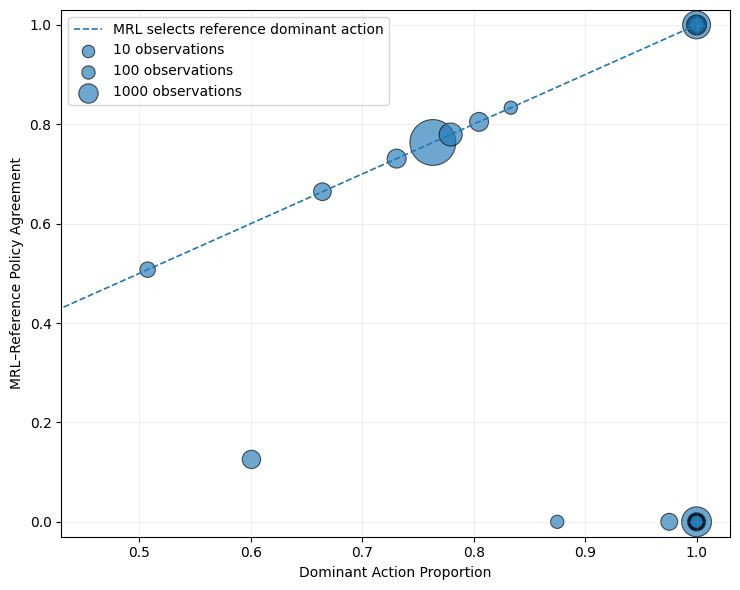

In [31]:
# ============================================================
# Plot cluster-level policy purity vs agreement
# ============================================================

plot_df = cluster_policy_summary.copy()

fig, ax = plt.subplots(figsize=(7.5, 6))

# Scale marker size by cluster sample size
max_n = plot_df["N_OBSERVATIONS"].max()
marker_sizes = 90 + 1000 * plot_df["N_OBSERVATIONS"] / max_n

scatter = ax.scatter(
    plot_df["TRUE_ACTION_PURITY"],
    plot_df["POLICY_AGREEMENT"],
    s=marker_sizes,
    alpha=0.65,
    edgecolors="black",
    linewidths=0.8,
)

# Diagonal: MRL selects the dominant simulator-optimal action
ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="MRL selects reference dominant action",
)

ax.set_xlabel("Dominant Action Proportion")
ax.set_ylabel("MRL–Reference Policy Agreement")
ax.set_xlim(0.43, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.grid(alpha=0.2)

# Marker-size legend
size_values = [10, 100, 1000]
size_handles = []
bubble_color = scatter.get_facecolor()[0]

for n in size_values:
    size = 80 + 900 * n / max_n
    size_handles.append(
        ax.scatter(
            [], [],
            s=size,
            color=bubble_color,
            alpha=0.65,
            edgecolors="black",
            linewidths=0.8,
            label=f"{n} observations",
        )
    )

ax.legend(
    handles=[ax.lines[0]] + size_handles,
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.savefig("cluster_policy_agreement.pdf", bbox_inches="tight")
plt.show()

### Latent Diabetes State Recovery

Evaluate whether the metastates learned by MRL recover information about the simulator's unobserved diabetes state.

Diabetes is not provided to MRL as an observed feature. Therefore, an association between metastates and diabetes indicates that the learned representation captures latent structure indirectly through its effect on observed dynamics and transition behavior.

- Mean and weighted cluster diabetic/non-diabetic purity
- Cluster-Diabetes NMI
- Cluster diabetes composition
- Features-Diabetes MI/NMI

#### Cluster diabetic/non-diabetic Purity & Cluster-Diabetes NMI

For each independently trained full `N` MRL model:

1. Match each observation with its true latent diabetes label using the trajectory ID.
2. Compute the diabetes composition of every learned metastate.
3. Quantify latent-state recovery using:
   - **Mean cluster purity:** average majority-class proportion across clusters.
   - **Weighted purity:** observation-weighted cluster purity.
   - **Normalized Mutual Information (NMI):** overall association between learned metastates and latent diabetes.
4. Aggregate the metrics across all independent trials and report **mean ± standard deviation**.

Interpretation:

- Higher **purity** indicates that individual metastates tend to contain observations from a single latent diabetes class.
- Higher **NMI** indicates that the learned partition preserves more information about the latent diabetes structure.

In [ ]:
# ============================================================
# 1. Match learned clusters with latent diabetes labels
# ============================================================

trial_results = []
cluster_composition_all = []
df_eval_all = {}

for repeat_idx, model in enumerate(
    all_mrl_models
):

    df_eval = (
        model.df_trained
        .copy()
    )

    diabetes_map = diabetes_maps[
        repeat_idx
    ]

    df_eval["DIABETES"] = (
        df_eval["ID"]
        .astype(int)
        .map(diabetes_map)
    )

    # Ensure that every trajectory has a diabetes label
    if df_eval["DIABETES"].isna().any():

        missing_ids = (
            df_eval.loc[
                df_eval["DIABETES"].isna(),
                "ID",
            ]
            .unique()
        )

        raise ValueError(
            f"Repeat {repeat_idx}: "
            f"missing diabetes labels for IDs "
            f"{missing_ids[:20]}"
        )

    df_eval["DIABETES"] = (
        df_eval["DIABETES"]
        .astype(int)
    )

    df_eval["CLUSTER"] = (
        df_eval["CLUSTER"]
        .astype(int)
    )

    # Keep the matched dataframe for later analysis
    df_eval_all[
        repeat_idx
    ] = df_eval.copy()

    # ========================================================
    # 2. Compute cluster-level diabetes composition
    # ========================================================

    counts = pd.crosstab(
        df_eval["CLUSTER"],
        df_eval["DIABETES"],
    )

    counts = counts.reindex(
        columns=[0, 1],
        fill_value=0,
    )

    counts.columns = [
        "NON_DIABETIC_COUNT",
        "DIABETIC_COUNT",
    ]

    counts["TOTAL"] = (
        counts.sum(axis=1)
    )

    counts["NON_DIABETIC_PROP"] = (
        counts["NON_DIABETIC_COUNT"]
        / counts["TOTAL"]
    )

    counts["DIABETIC_PROP"] = (
        counts["DIABETIC_COUNT"]
        / counts["TOTAL"]
    )


    # ========================================================
    # 3. Compute recovery metrics
    # ========================================================

    counts["PURITY"] = (
        counts[
            [
                "NON_DIABETIC_COUNT",
                "DIABETIC_COUNT",
            ]
        ]
        .max(axis=1)
        / counts["TOTAL"]
    )

    counts = counts.reset_index()

    counts[
        "REPEAT"
    ] = repeat_idx

    cluster_composition_all.append(
        counts.copy()
    )


    # Equal weight for every learned cluster
    mean_cluster_purity = (
        counts["PURITY"]
        .mean()
    )

    # Weight clusters according to their number of observations
    weighted_purity = (
        (
            counts["PURITY"]
            * counts["TOTAL"]
        ).sum()
        / counts["TOTAL"].sum()
    )


    nmi = normalized_mutual_info_score(
        df_eval["DIABETES"],
        df_eval["CLUSTER"],
    )


    # ========================================================
    # 5. Store trial-level metrics
    # ========================================================

    trial_results.append(
        {
            "REPEAT": repeat_idx,
            "N": N_max,
            "N_CLUSTERS": (
                df_eval["CLUSTER"].nunique()
            ),
            "N_OBSERVATIONS": len(df_eval),
            "MEAN_CLUSTER_PURITY": mean_cluster_purity,
            "WEIGHTED_PURITY": weighted_purity,
            "NMI": nmi,
        }
    )

In [ ]:
# ============================================================
# 6. Combine trial-level results
# ============================================================

trial_results = pd.DataFrame(
    trial_results
)

cluster_composition_all = pd.concat(
    cluster_composition_all,
    ignore_index=True,
)


# ============================================================
# 7. Summary across independent repeats
# ============================================================

summary = pd.DataFrame(
    {
        "Mean": [
            trial_results[
                "MEAN_CLUSTER_PURITY"
            ].mean(),

            trial_results[
                "WEIGHTED_PURITY"
            ].mean(),

            trial_results[
                "NMI"
            ].mean(),

            trial_results[
                "N_CLUSTERS"
            ].mean(),
        ],

        "Std": [
            trial_results[
                "MEAN_CLUSTER_PURITY"
            ].std(ddof=1),

            trial_results[
                "WEIGHTED_PURITY"
            ].std(ddof=1),

            trial_results[
                "NMI"
            ].std(ddof=1),

            trial_results[
                "N_CLUSTERS"
            ].std(ddof=1),
        ],
    },

    index=[
        "Mean cluster purity",
        "Weighted purity",
        "NMI",
        "Number of clusters",
    ],
)


print(
    "=== Latent-state recovery: "
    "trial-level results ==="
)

display(
    trial_results.round(4)
)


print(
    "\n=== Latent-state recovery: "
    "mean ± SD across repeats ==="
)

display(
    summary.round(4)
)

=== Latent-state recovery: trial-level results ===


,REPEAT,N,N_CLUSTERS,N_OBSERVATIONS,MEAN_CLUSTER_PURITY,WEIGHTED_PURITY,NMI
0,0,100,61,1034,0.8732,0.8801,0.1038
1,1,100,55,990,0.8765,0.8636,0.0858
2,2,100,51,1011,0.9116,0.9130,0.0498
3,3,100,50,974,0.8178,0.8306,0.0797
4,4,100,45,960,0.9134,0.9010,0.0663
5,5,100,61,949,0.9057,0.8925,0.0969
6,6,100,53,978,0.9019,0.8947,0.0912
7,7,100,52,1072,0.9151,0.9170,0.0412
8,8,100,56,892,0.8998,0.8946,0.1407
9,9,100,63,1094,0.8793,0.8940,0.0672



=== Latent-state recovery: mean ± SD across repeats ===


,Mean,Std
Mean cluster purity,0.8894,0.0297
Weighted purity,0.8881,0.0252
NMI,0.0823,0.0287
Number of clusters,54.7000,5.6774


#### Cluster diabetes composition

This is a representative Cluster Diabetes Composition. One representative MRL model is selected for visualization.

This analysis reports the diabetes composition of every learned metastate and visualizes the proportion of diabetic and non-diabetic observations within each cluster.

In [ ]:
# ============================================================
# 1. Extract cluster composition from one representative model
# ============================================================

representative_repeat = 9

comp_example = (
    cluster_composition_all.loc[
        cluster_composition_all["REPEAT"]
        == representative_repeat
    ]
    .sort_values("CLUSTER")
    .copy()
)


print(
    f"=== Cluster diabetes composition: "
    f"Repeat {representative_repeat} ==="
)

display(
    comp_example[
        [
            "CLUSTER",
            "NON_DIABETIC_COUNT",
            "DIABETIC_COUNT",
            "TOTAL",
            "NON_DIABETIC_PROP",
            "DIABETIC_PROP",
            "PURITY",
        ]
    ].round(4)
)

=== Cluster diabetes composition: Repeat 9 ===


,CLUSTER,NON_DIABETIC_COUNT,DIABETIC_COUNT,TOTAL,NON_DIABETIC_PROP,DIABETIC_PROP,PURITY
484,0,47,5,52,0.9038,0.0962,0.9038
485,1,66,10,76,0.8684,0.1316,0.8684
486,2,5,1,6,0.8333,0.1667,0.8333
487,3,12,0,12,1.0000,0.0000,1.0000
488,4,26,1,27,0.9630,0.0370,0.9630
...,...,...,...,...,...,...,...
542,58,23,1,24,0.9583,0.0417,0.9583
543,59,11,0,11,1.0000,0.0000,1.0000
544,60,11,1,12,0.9167,0.0833,0.9167
545,61,17,0,17,1.0000,0.0000,1.0000


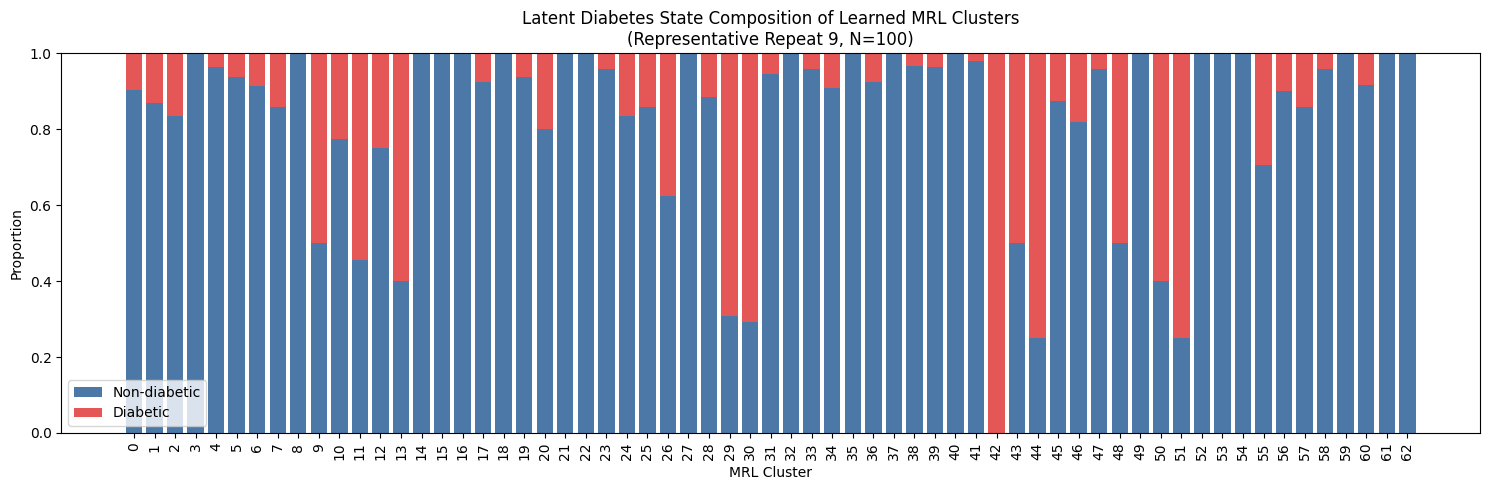

In [ ]:
# ============================================================
# 2. Visualize cluster diabetes composition
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 5)
)

x = np.arange(
    len(comp_example)
)

ax.bar(
    x,
    comp_example[
        "NON_DIABETIC_PROP"
    ],
    label="Non-diabetic",
    color="#4C78A8",
)

ax.bar(
    x,
    comp_example[
        "DIABETIC_PROP"
    ],
    bottom=comp_example[
        "NON_DIABETIC_PROP"
    ],
    label="Diabetic",
    color="#E45756",
)

ax.set_xticks(x)

ax.set_xticklabels(
    comp_example["CLUSTER"],
    rotation=90,
)

ax.set_ylim(0, 1)

ax.set_xlabel(
    "MRL Cluster"
)

ax.set_ylabel(
    "Proportion"
)

ax.set_title(
    "Latent Diabetes State Composition "
    "of Learned MRL Clusters\n"
    f"(Representative Repeat {representative_repeat}, "
    f"N={N_max})"
)

ax.legend()

plt.tight_layout()
plt.show()

#### Features-Diabetes MI/NMI

This section investigates the mutual information between latent diabetes and each observed clinical feature individually.

Interpretation:

- Higher MI/NMI indicates that a variable contains more information about the latent diabetes state.
- If the learned MRL metastates achieve comparable or higher MI/NMI than individual observed features, this suggests that the learned representation integrates diabetes-related information distributed across multiple clinical variables rather than relying on a single feature.

The comparison is performed on the same representative MRL model used in the cluster-composition visualization.

In [ ]:
# ============================================================
# Compare latent diabetes information
# ============================================================

df_eval = (
    df_eval_all[
        representative_repeat
    ]
    .copy()
)

diabetes_information = []

# Mutual information between each feature and the latent diabetes state
for feature in feature_cols:

    diabetes_information.append(
        {
            "Feature": feature_names[
                feature
            ],

            "MI": mutual_info_score(
                df_eval["DIABETES"],
                df_eval[feature],
            ),

            "NMI": normalized_mutual_info_score(
                df_eval["DIABETES"],
                df_eval[feature],
            ),
        }
    )

# Mutual information between the metastates and the latent diabetes state
diabetes_information.append(
    {
        "Feature": "MRL Cluster",

        "MI": mutual_info_score(
            df_eval["DIABETES"],
            df_eval["CLUSTER"],
        ),

        "NMI": normalized_mutual_info_score(
            df_eval["DIABETES"],
            df_eval["CLUSTER"],
        ),
    }
)

# Rank variables according to nmi
diabetes_information = (
    pd.DataFrame(
        diabetes_information
    )
    .sort_values(
        "NMI",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "=== Information about latent diabetes "
    f"(Representative Repeat {representative_repeat}) ==="
)

display(
    diabetes_information.round(4)
)

=== Information about latent diabetes (Representative Repeat 9) ===


,Feature,MI,NMI
0,Glucose,0.1459,0.1646
1,MRL Cluster,0.1430,0.0672
2,Heart Rate,0.0133,0.0215
3,Systolic BP,0.0021,0.0032
4,Vasopressors,0.0001,0.0002
5,Ventilation,0.0000,0.0001
6,Oxygen Saturation,0.0000,0.0000
7,Antibiotics,0.0000,0.0000
